In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score, classification_report
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
import xgboost as xgb
import shap
import seaborn as sns

### Loading df

In [2]:
df = pd.read_csv('../Dataset/Processed/Merged_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,OVX_Close,TTF_Gas_Close,VIX_Close,Gold_Close,EBITDA,Net_Income,ROA,Total_Assets,Total_Debt,Cash
615957,2025-12-19,7.58,7.61,7.54,7.57,53.8,ZIGNAGO VETRO,2.8925,1.1708,40683.0,...,33.62,28.20,14.91,3703.98,NaN,NaN,NaN,NaN,NaN,NaN
615958,2025-12-22,7.63,7.70,7.48,7.57,91.6,ZIGNAGO VETRO,2.9044,1.1760,48571.0,...,33.03,27.77,14.08,3777.43,NaN,NaN,NaN,NaN,NaN,NaN
615959,2025-12-23,7.67,7.75,7.61,7.71,50.4,ZIGNAGO VETRO,2.8647,1.1794,55315.0,...,33.02,27.78,14.00,3800.40,NaN,NaN,NaN,NaN,NaN,NaN
615960,2025-12-29,7.79,7.80,7.63,7.63,78.6,ZIGNAGO VETRO,2.8257,1.1772,50852.0,...,32.16,28.69,14.20,3679.45,NaN,NaN,NaN,NaN,NaN,NaN
615961,2025-12-30,7.77,7.84,7.72,7.82,42.7,ZIGNAGO VETRO,2.8533,1.1746,44821.0,...,30.76,27.80,14.33,3691.29,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_yoy = pd.read_csv('../Dataset/Processed/Merged_Dataset_yoy.csv')
df_yoy['Date'] = pd.to_datetime(df_yoy['Date'])
df_yoy.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,OVX_Close,TTF_Gas_Close,VIX_Close,Gold_Close,EBITDA,Net_Income,ROA,Total_Assets,Total_Debt,Cash
615932,2025-12-19,7.58,7.61,7.54,7.57,53.8,ZIGNAGO VETRO,2.8925,1.1708,40683.0,...,33.62,28.20,14.91,3703.98,NaN,NaN,NaN,NaN,NaN,NaN
615933,2025-12-22,7.63,7.70,7.48,7.57,91.6,ZIGNAGO VETRO,2.9044,1.1760,48571.0,...,33.03,27.77,14.08,3777.43,NaN,NaN,NaN,NaN,NaN,NaN
615934,2025-12-23,7.67,7.75,7.61,7.71,50.4,ZIGNAGO VETRO,2.8647,1.1794,55315.0,...,33.02,27.78,14.00,3800.40,NaN,NaN,NaN,NaN,NaN,NaN
615935,2025-12-29,7.79,7.80,7.63,7.63,78.6,ZIGNAGO VETRO,2.8257,1.1772,50852.0,...,32.16,28.69,14.20,3679.45,NaN,NaN,NaN,NaN,NaN,NaN
615936,2025-12-30,7.77,7.84,7.72,7.82,42.7,ZIGNAGO VETRO,2.8533,1.1746,44821.0,...,30.76,27.80,14.33,3691.29,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
num_companies = df_yoy['Company'].nunique()
print(f"Number of companies in the dataset: {num_companies}")

oldest_date = df_yoy['Date'].min()
print(f"Oldest date in the dataset: {oldest_date}")

Number of companies in the dataset: 186
Oldest date in the dataset: 2009-09-18 00:00:00


In [5]:
features = [
    'Close', 'Volume', 
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 
    'Euribor_3M', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 
    'IT10YT_Yield', 'IT_Inflation', 'IT_GDP', 'IT_Unemployment', 
    'Brent_Close', 'Brent_Volume', 'OVX_Close', 
    'TTF_Gas_Close', 'VIX_Close', 'Gold_Close'
]

targets = ['EBITDA', 'ROA', 'Net_Income']

In [6]:
log_targets = []
df_yoy = df_yoy.sort_values(by=['Company', 'Date']).reset_index(drop=True)

for target in targets:
    new_target_name = f'{target}_LogReturn'
    log_targets.append(new_target_name)

    valid_reports = df_yoy[df_yoy[target].notna()].copy()
    valid_reports[new_target_name] = valid_reports.groupby('Company')[target].transform(
        lambda x: (np.sign(x) * np.log1p(np.abs(x))) - (np.sign(x.shift(1)) * np.log1p(np.abs(x.shift(1))))
    )
    df_yoy[new_target_name] = valid_reports[new_target_name]

sample_check = df_yoy[df_yoy['EBITDA_LogReturn'].notna()]
print("\nSample of Annual EBITDA to EBITDA_LogReturn transformation:")
print(sample_check[['Company', 'Date', 'EBITDA', 'EBITDA_LogReturn']].head(10).to_string(index=False))


Sample of Annual EBITDA to EBITDA_LogReturn transformation:
Company       Date    EBITDA  EBITDA_LogReturn
    A2A 2010-12-30  696000.0         -0.176076
    A2A 2011-12-30  603000.0         -0.143432
    A2A 2012-12-28  984000.0          0.489708
    A2A 2013-12-30 1265000.0          0.251201
    A2A 2014-12-30  770000.0         -0.496436
    A2A 2015-12-30  611000.0         -0.231293
    A2A 2016-12-30  917000.0          0.406010
    A2A 2017-12-29 1099000.0          0.181048
    A2A 2018-12-28 1061000.0         -0.035189
    A2A 2019-12-30 1181000.0          0.107150


In [7]:
param_distributions = {
    'n_estimators': [400, 700, 1000, 1300],
    'max_depth': [None, 10, 16, 24, 32],
    'min_samples_split': [2, 4, 8, 12],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
    'bootstrap': [True],
    'criterion': ['squared_error', 'absolute_error']
}

def fit_rf(X_train_local, y_train_local):
    base_rf = RandomForestRegressor(random_state=42, oob_score=False)
    rf_search = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=param_distributions,
        n_iter=35,
        cv=4,
        scoring='neg_mean_absolute_error',
        random_state=42,
        n_jobs=-1
    )
    rf_search.fit(X_train_local, y_train_local)
    return rf_search.best_estimator_, rf_search.best_params_

def signed_log_transform(y):
    return np.sign(y) * np.log1p(np.abs(y))

def signed_log_inverse(y):
    return np.sign(y) * np.expm1(np.abs(y))

def regression_metrics(y_true, y_pred):
    eps = 1e-8
    abs_err = np.abs(y_pred - y_true)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    avg_pct_diff = float(np.mean(abs_err / np.maximum(np.abs(y_true), eps)) * 100.0)
    median_pct_diff = float(np.median(abs_err / np.maximum(np.abs(y_true), eps)) * 100.0)
    wape = float(np.sum(abs_err) / np.maximum(np.sum(np.abs(y_true)), eps) * 100.0)
    smape = float(
        np.mean(2.0 * abs_err / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100.0
    )
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'AvgPctDiff': avg_pct_diff,
        'MedianPctDiff': median_pct_diff,
        'WAPE': wape,
        'sMAPE': smape
    }

def compute_mutual_information(X_train_local, y_train_local, task='regression', random_state=42):
    if task == 'classification':
        mi_scores = mutual_info_classif(
            X_train_local,
            y_train_local,
            random_state=random_state
        )
        score_col = 'MI_Classif'
    else:
        mi_scores = mutual_info_regression(
            X_train_local,
            y_train_local,
            random_state=random_state
        )
        score_col = 'MI_Regression'

    mi_df = pd.DataFrame({
        'Feature': X_train_local.columns,
        score_col: mi_scores
    }).sort_values(by=score_col, ascending=False).reset_index(drop=True)

    return mi_df, score_col

def fit_xgb_classifier(X_train_scaled, y_train):
    imbalance_ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
    base_xgb = xgb.XGBClassifier(
        random_state=42,
        eval_metric='auc',
        scale_pos_weight=imbalance_ratio,
        n_jobs=-1
    )
    
    param_distributions = {
        'n_estimators': [200, 400, 600, 800, 1000],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.5, 1, 5]
    }

    xgb_search = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_distributions,
        n_iter=150,
        cv=4,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    xgb_search.fit(X_train_scaled, y_train)
    return xgb_search.best_estimator_, xgb_search.best_params_

# Exploratory Data Analysis

In [11]:
def build_date_level_macro_timeline(df_input, feature_list):
    df_clean = df_input.copy()
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    df_clean = df_clean.sort_values(by=['Company', 'Date']).reset_index(drop=True)

    date_level_features = []
    company_level_features = []
    for feat in feature_list:
        max_nunique_per_date = df_clean.groupby('Date')[feat].nunique(dropna=True).max()
        if pd.isna(max_nunique_per_date) or max_nunique_per_date <= 1:
            date_level_features.append(feat)
        else:
            company_level_features.append(feat)

    if not date_level_features:
        raise ValueError("No date-level features found for lead-lag macro analysis.")

    macro_timeline = (
        df_clean[['Date'] + date_level_features]
        .drop_duplicates(subset=['Date'])
        .sort_values('Date')
        .set_index('Date')
        .ffill()
        .dropna()
        .sort_index()
    )

    return df_clean, macro_timeline, date_level_features, company_level_features


def plot_macro_lead_lag_heatmaps(
    df_input,
    feature_list,
    target_columns,
    trading_lags=None,
    trading_year=252,
    min_rolling_periods=200,
    min_samples=30,
    figsize=(18, 8),
    y_label="Macro Date-Level Features",
):
    if trading_lags is None:
        trading_lags = {0: '0M', 63: '3M', 126: '6M', 189: '9M', 252: '12M'}

    df_clean, macro_timeline, date_level_features, company_level_features = build_date_level_macro_timeline(
        df_input, feature_list
    )

    macro_rolling_avg = macro_timeline.rolling(window=trading_year, min_periods=min_rolling_periods).mean()
    lag_labels = list(trading_lags.values())

    fig, axes = plt.subplots(1, len(target_columns), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    heatmap_outputs = {}

    for i, target_col in enumerate(target_columns):
        print(f"Processing Lead-Lag for: {target_col}...")
        heatmap_matrix = {feat: [] for feat in date_level_features}
        report_dates = df_clean[df_clean[target_col].notna()][['Date', target_col]].copy()

        for feat in date_level_features:
            for lag_bars in trading_lags.keys():
                shifted_macro = macro_rolling_avg[feat].shift(lag_bars + 1)
                aligned_df = report_dates.join(shifted_macro, on='Date', how='inner').dropna()

                if len(aligned_df) > min_samples:
                    corr = aligned_df[target_col].corr(aligned_df[feat], method='spearman')
                    heatmap_matrix[feat].append(corr)
                else:
                    heatmap_matrix[feat].append(np.nan)

        plot_df = pd.DataFrame(heatmap_matrix, index=lag_labels).T
        heatmap_outputs[target_col] = plot_df

        sns.heatmap(
            plot_df,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt=".2f",
            linewidths=.5,
            cbar=(i == len(target_columns) - 1),
            ax=axes[i],
        )

        axes[i].set_title(f"Lead-Lag: {target_col}", fontsize=13, fontweight='bold')
        axes[i].set_xlabel("Lag (Trading Months)")
        if i == 0:
            axes[i].set_ylabel(y_label)
        else:
            axes[i].set_ylabel("")

    plt.tight_layout()
    plt.show()

    return heatmap_outputs, date_level_features, company_level_features


Processing Lead-Lag for: EBITDA_LogReturn...
Processing Lead-Lag for: ROA_LogReturn...
Processing Lead-Lag for: Net_Income_LogReturn...


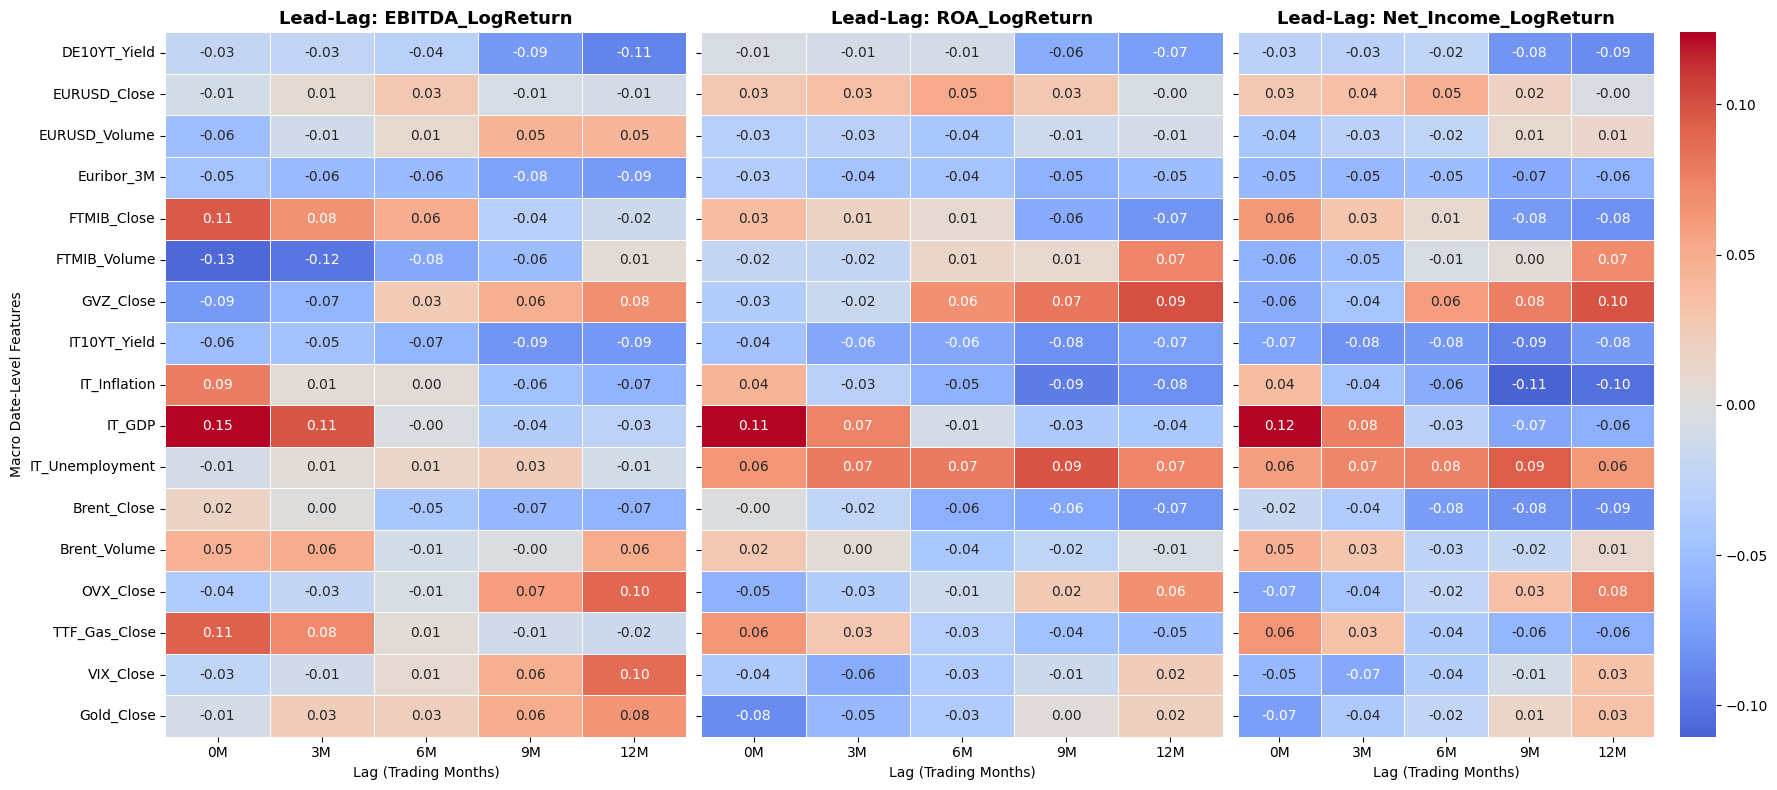

In [14]:
lead_lag_log_outputs, _, _ = plot_macro_lead_lag_heatmaps(
    df_input=df_yoy,
    feature_list=features,
    target_columns=log_targets,
    figsize=(18, 8),
)

Total days analyzed: 4135
Date-level macro features used: 17
Maximum simultaneous shocks in one day: 10 features


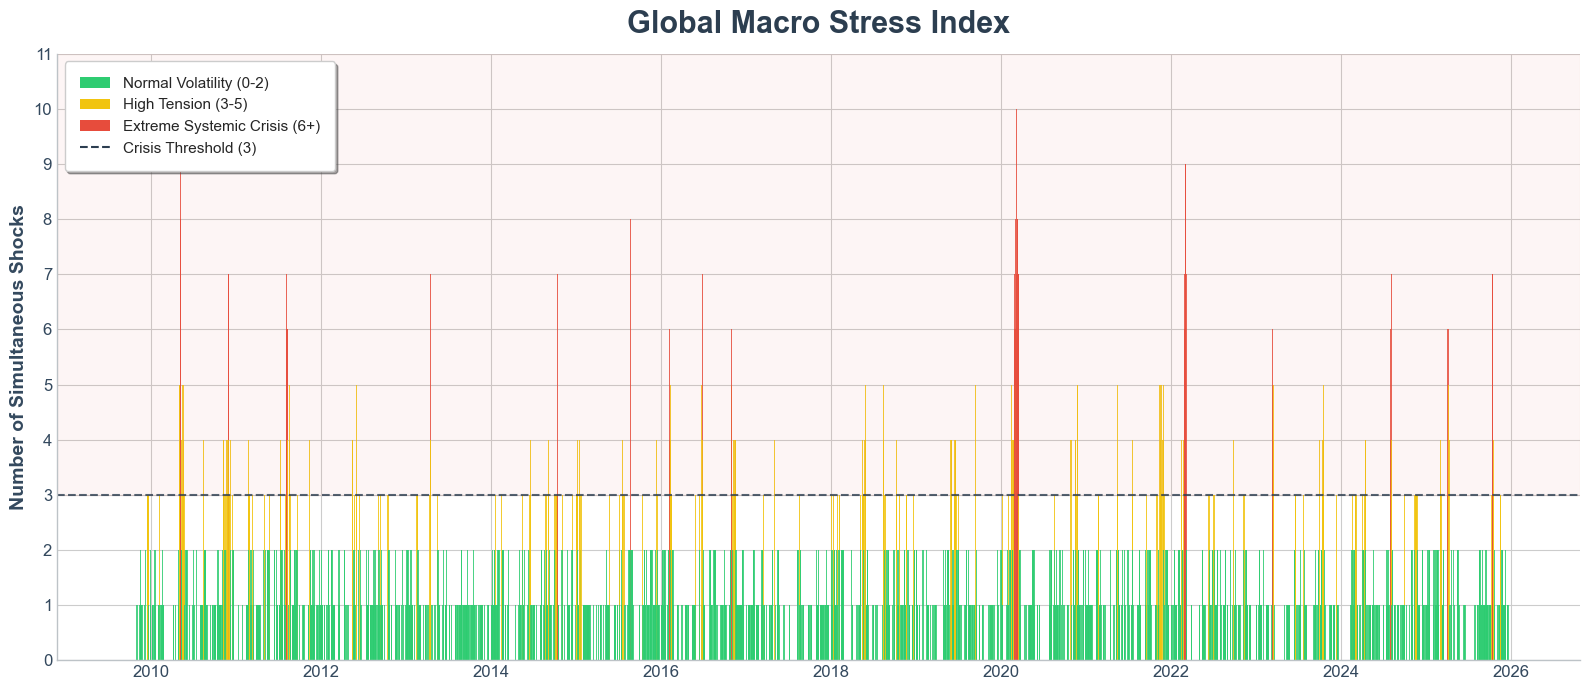


Top 5 Days with Highest Macro Stress:
- 2020-03-09: 10 simultaneous shocks (58.8% of features)
  Features: DE10YT_Yield, EURUSD_Close, EURUSD_Volume, FTMIB_Close, FTMIB_Volume, GVZ_Close, Brent_Close, Brent_Volume, OVX_Close, VIX_Close

- 2010-05-07: 9 simultaneous shocks (52.9% of features)
  Features: DE10YT_Yield, EURUSD_Close, FTMIB_Close, FTMIB_Volume, IT10YT_Yield, OVX_Close, TTF_Gas_Close, VIX_Close, Gold_Close

- 2022-03-04: 9 simultaneous shocks (52.9% of features)
  Features: EURUSD_Close, Euribor_3M, FTMIB_Close, FTMIB_Volume, GVZ_Close, Brent_Close, OVX_Close, TTF_Gas_Close, Gold_Close

- 2022-03-07: 9 simultaneous shocks (52.9% of features)
  Features: EURUSD_Close, FTMIB_Close, FTMIB_Volume, GVZ_Close, Brent_Close, OVX_Close, TTF_Gas_Close, VIX_Close, Gold_Close

- 2020-03-12: 8 simultaneous shocks (47.1% of features)
  Features: EURUSD_Volume, FTMIB_Close, FTMIB_Volume, GVZ_Close, IT10YT_Yield, Brent_Close, OVX_Close, VIX_Close



In [16]:
TRADING_QUARTER = 63
Z_SCORE_THRESHOLD = 2.5 

_, macro_daily, date_level_features, excluded_features = build_date_level_macro_timeline(df_yoy, features)
rolling_mean = macro_daily.rolling(window=TRADING_QUARTER, min_periods=30).mean()
rolling_std = macro_daily.rolling(window=TRADING_QUARTER, min_periods=30).std()

safe_std = rolling_std.replace(0, np.nan)
z_scores = (macro_daily - rolling_mean) / safe_std
z_scores = z_scores.replace([np.inf, -np.inf], np.nan)

anomalies_matrix = z_scores.abs() > Z_SCORE_THRESHOLD

global_stress_index = anomalies_matrix.sum(axis=1)
stress_ratio = global_stress_index / len(date_level_features)

stress_df = pd.DataFrame({
    'Stress_Score': global_stress_index,
    'Stress_Ratio': stress_ratio,
})

print(f"Total days analyzed: {len(stress_df)}")
print(f"Date-level macro features used: {len(date_level_features)}")
print(f"Maximum simultaneous shocks in one day: {int(stress_df['Stress_Score'].max())} features")

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 7))
colors = [
    '#2ecc71' if score < 3 else '#f1c40f' if score < 6 else '#e74c3c'
    for score in stress_df['Stress_Score']
]
ax.bar(stress_df.index, stress_df['Stress_Score'], color=colors, width=4.0, alpha=0.85)

CRISIS_THRESHOLD = int(stress_df['Stress_Score'].quantile(0.95))
ax.axhline(y=CRISIS_THRESHOLD, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axhspan(
    CRISIS_THRESHOLD,
    stress_df['Stress_Score'].max() + 1,
    color='#e74c3c',
    alpha=0.05,
    label='Systemic Risk Zone',
)

ax.set_title("Global Macro Stress Index", fontsize=22, fontweight='bold', color='#2c3e50', pad=15)
ax.set_ylabel("Number of Simultaneous Shocks", fontsize=14, color='#34495e', fontweight='bold')
ax.set_xlabel("")

ax.set_ylim(0, stress_df['Stress_Score'].max() + 0.5)
ax.set_yticks(range(0, int(stress_df['Stress_Score'].max()) + 2))

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(fontsize=12, color='#34495e')
plt.yticks(fontsize=12, color='#34495e')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

legend_elements = [
    Patch(facecolor='#2ecc71', label='Normal Volatility (0-2)'),
    Patch(facecolor='#f1c40f', label='High Tension (3-5)'),
    Patch(facecolor='#e74c3c', label='Extreme Systemic Crisis (6+)'),
    plt.Line2D([0], [0], color='#2c3e50', lw=1.5, linestyle='--', label=f'Crisis Threshold ({CRISIS_THRESHOLD})'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

print("\nTop 5 Days with Highest Macro Stress:")
top_panic_days = stress_df.sort_values(by='Stress_Score', ascending=False).head(5)
for date, row in top_panic_days.iterrows():
    print(f"- {date.date()}: {int(row['Stress_Score'])} simultaneous shocks ({row['Stress_Ratio']:.1%} of features)")
    active_shocks = anomalies_matrix.loc[date]
    shocked_feats = active_shocks[active_shocks].index.tolist()
    print(f"  Features: {', '.join(shocked_feats)}\n")

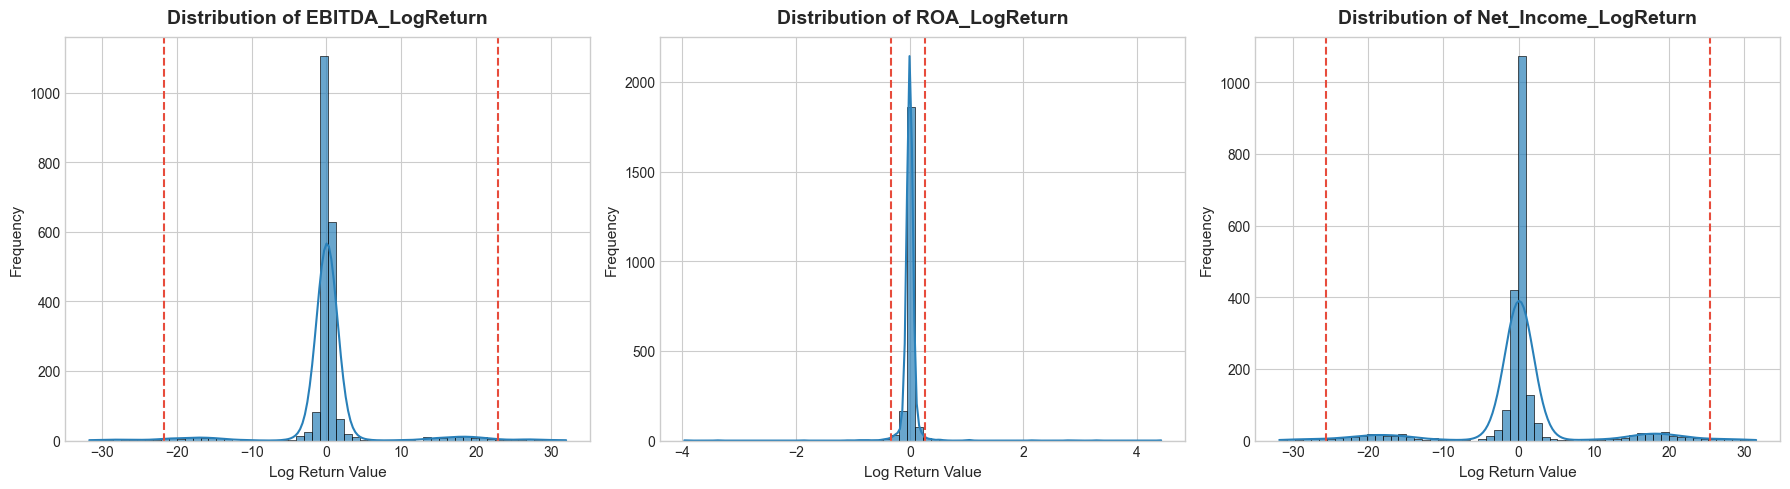

In [18]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, len(log_targets), figsize=(18, 5))
axes = np.atleast_1d(axes)

for i, target_col in enumerate(log_targets):
    valid_data = df_yoy[target_col].dropna()

    sns.histplot(valid_data, bins=60, kde=True, ax=axes[i], color='#2980b9', alpha=0.7)
    p01 = valid_data.quantile(0.01)
    p99 = valid_data.quantile(0.99)
    axes[i].axvline(p01, color='#e74c3c', linestyle='--', linewidth=1.5)
    axes[i].axvline(p99, color='#e74c3c', linestyle='--', linewidth=1.5)

    axes[i].set_title(f"Distribution of {target_col}", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Log Return Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)

plt.tight_layout()
plt.show()

# Feature Selection & Target Engineering Pipeline
This section of the study aims to identify the most predictive features (market data and macroeconomic indicators) for forecasting corporate fundamental targets (EBITDA, ROA, Net Income). Because the dataset contains sequential financial data, 90-day lookback windows prior to each financial report release are extracted, calculating the **mean** (Level/Trend) and **standard deviation** (Volatility/Shock)for each feature.

To ensure robust and unbiased feature selection, three distinct mathematical frameworks are employed:

**1. Mutual Information**

Mutual Information (MI) is a non-parametric metric that measures the reduction in uncertainty about the target variable given the knowledge of a specific feature. Unlike traditional Pearson correlation, MI is completely model-agnostic and can capture complex, non-linear relationships between macroeconomic shocks and corporate fundamentals.

**2. Random Forest & Gini Importance**

Random Forest is an ensemble learning method and the feature importance is calculated using the Gini Importance (Mean Decrease in Impurity) metric. 
It calculates how much each feature contributes to reducing the variance (in regression) or impurity (in classification) across all the decision trees in the forest. It provides an excellent measure of the absolute predictive power of a variable.

**3. SHAP Values**

While Random Forest shows how much a feature matters, SHAP (SHapley Additive exPlanations) explains how it matters: it values break down the prediction to show the directional impact of each feature. A SHAP summary plot allows us to visually understand whether a high value of a specific feature pushes the model's prediction higher or lower, providing crucial economic interpretability to our black-box models. Red dots indicate that a high value of the feature increases the probability of an upward trend, while blue dots indicate that a high value decreases it. If the dots are on the right side of the plot, it means that the feature pushes the prediction towards an upward trend; if they are on the left, it means that the feature pushes the prediction towards a downward trend.

## Part 1: Absolute Target Analysis - Regression

In this first analytical phase, the algorithms are tasked with predicting the absolute values of the financial targets. 

This approach serves as a baseline to test the models' behavior on raw, unscaled accounting data. We treat this as a continuous Regression problem using `RandomForestRegressor` and `mutual_info_regression`.

### Quarters: Exogenous Variables Only


                                EBITDA                                
Total valid 90-day windows extracted: 8826

Top 10 features by Mutual Information:
        Feature  MI_Regression
     Close_MEAN       1.106623
     Close_LAST       1.049694
    Volume_MEAN       0.683772
    Volume_LAST       0.552302
     Volume_STD       0.489991
      Close_STD       0.448789
   Volume_TREND       0.267997
    Close_TREND       0.144456
Euribor_3M_LAST       0.079546
Euribor_3M_MEAN       0.068340


/Users/davide/UniPD/Tesi/xLSTM/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/davide/UniPD/Tesi/xLSTM/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Model comparison (test metrics):
Raw Target RF  -> R2: 0.7376 | MAE: 343433.3956 | RMSE: 1350049.3232 | Avg % Diff: 620.71% | WAPE: 45.18% | sMAPE: 78.21%
Signed-Log RF  -> R2: 0.4209 | MAE: 472899.4365 | RMSE: 2005521.4318 | Avg % Diff: 267.77% | WAPE: 62.21% | sMAPE: 96.76%

Selected model for EBITDA: Raw-Target RF (selected)
Best RF Params for EBITDA: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 190705.2279 | RMSE: 601739.0898 | R2: 0.9509 | Avg % Diff: 320.49% | Median % Diff: 43.84% | WAPE: 23.98% | sMAPE: 68.50%
Test  -> MAE: 343433.3956 | RMSE: 1350049.3232 | R2: 0.7376 | Avg % Diff: 620.71% | Median % Diff: 54.99% | WAPE: 45.18% | sMAPE: 78.21%


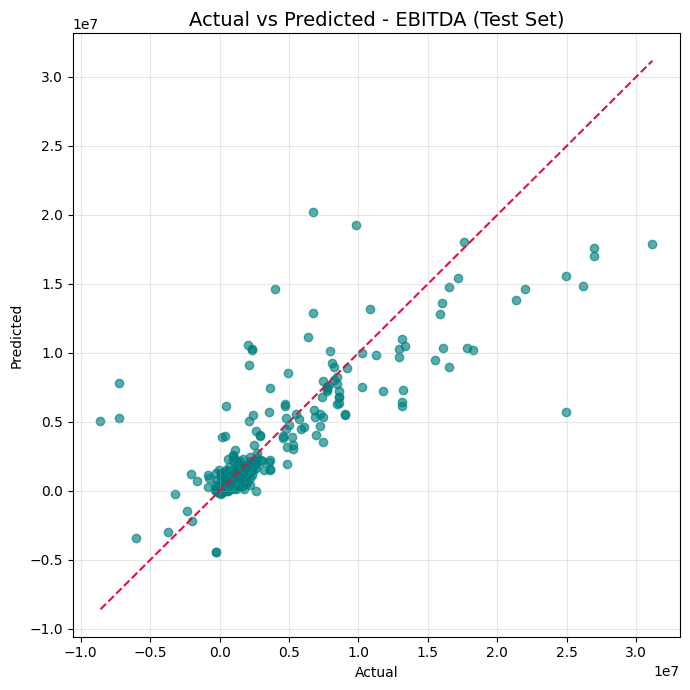

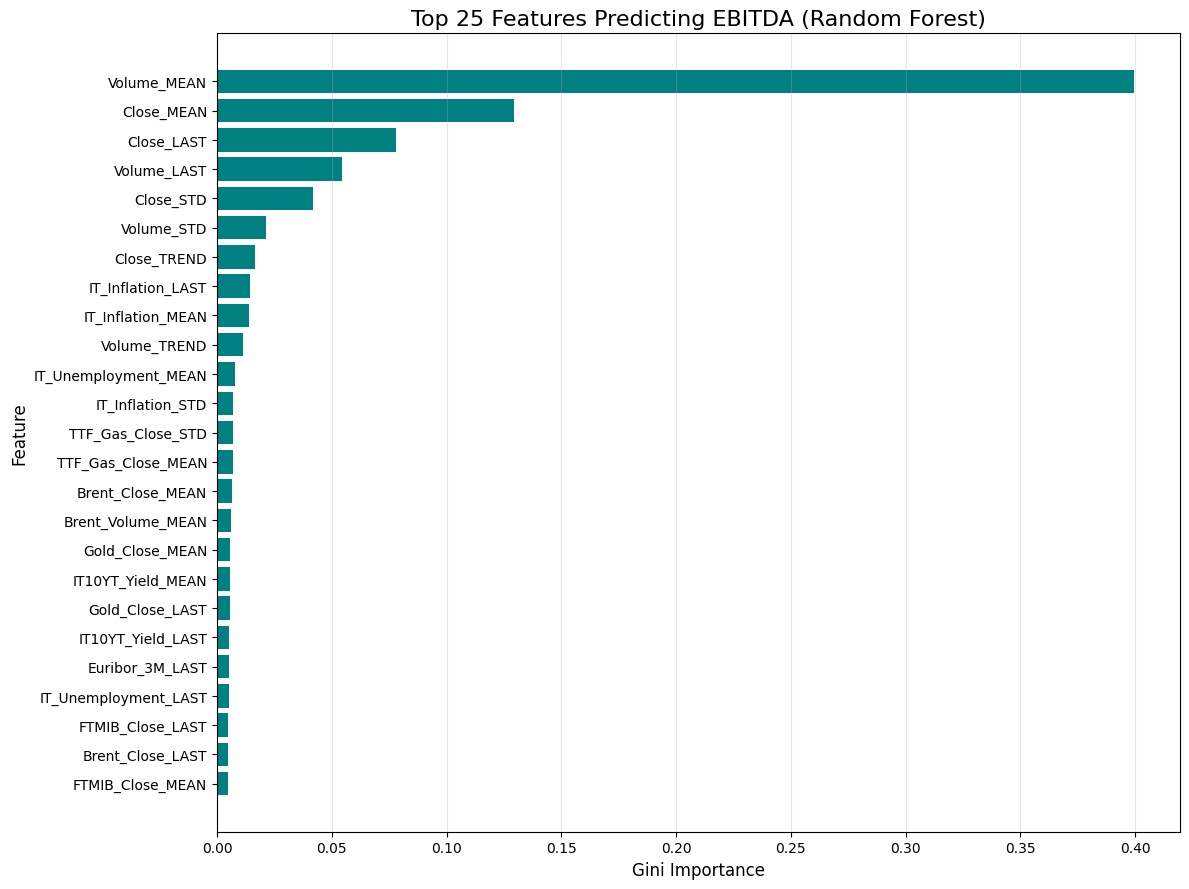

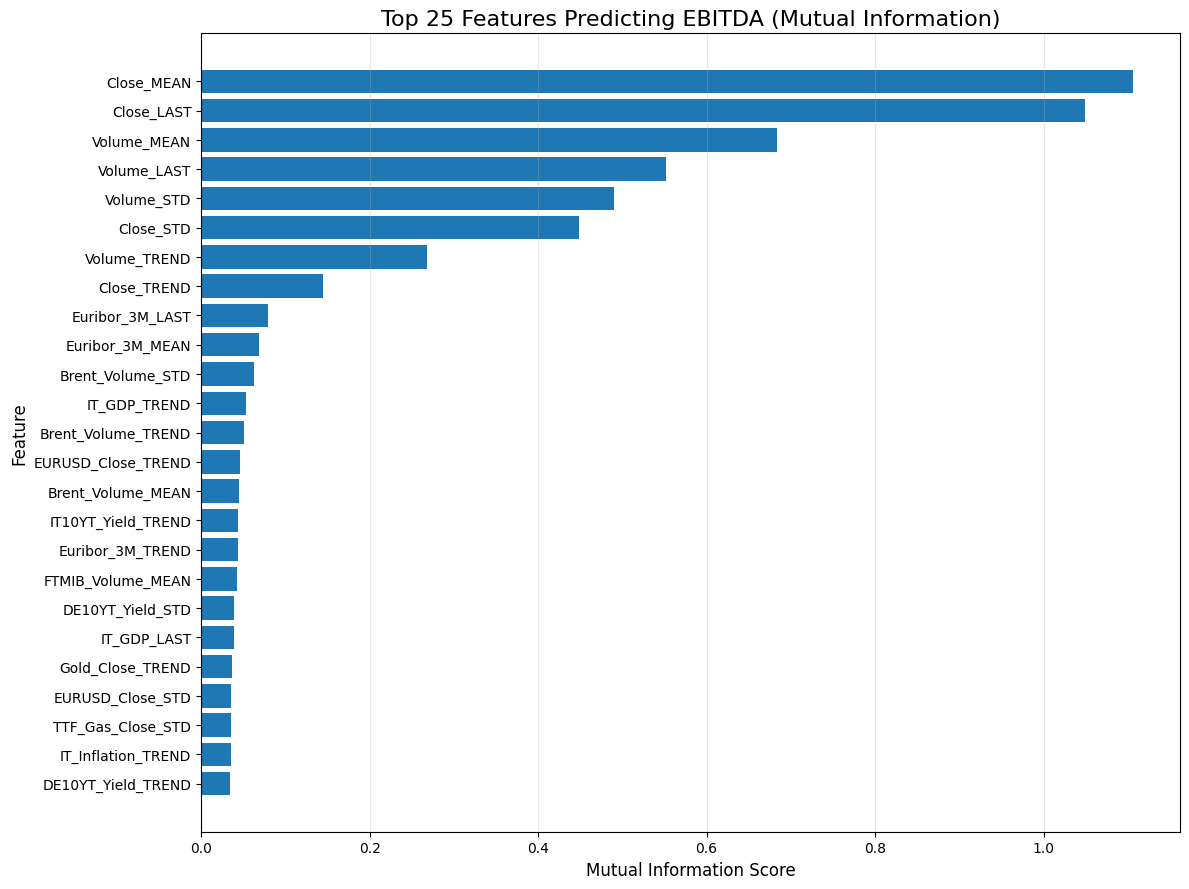

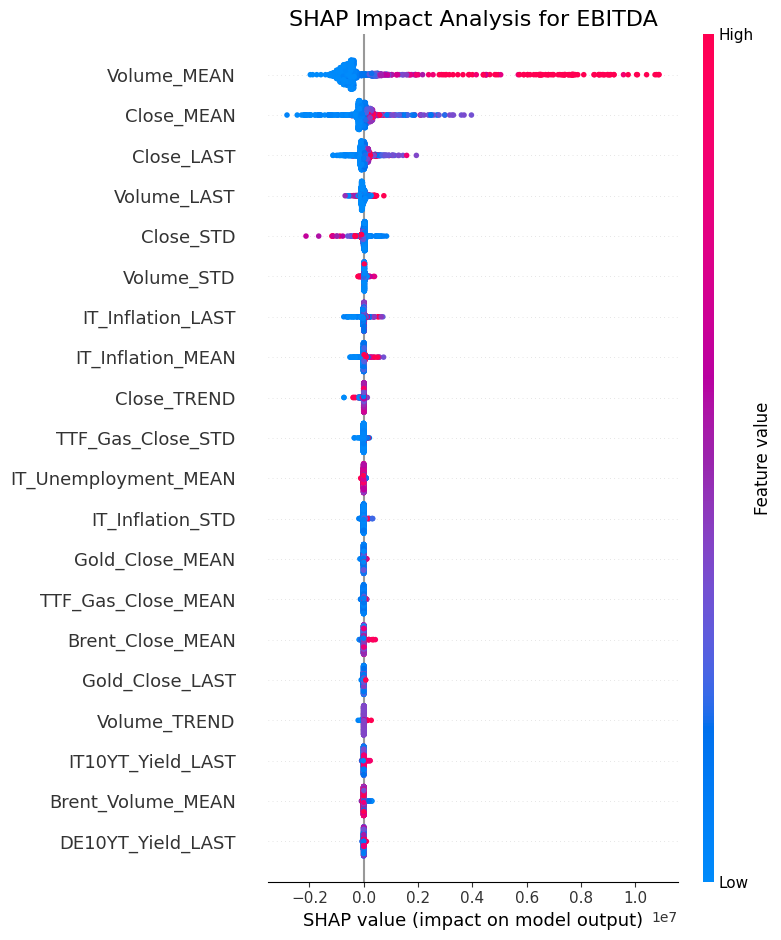


                                 ROA                                  
Total valid 90-day windows extracted: 8972

Top 10 features by Mutual Information:
        Feature  MI_Regression
     Close_MEAN       1.111431
     Close_LAST       1.070713
      Close_STD       0.449159
    Volume_MEAN       0.317667
     Volume_STD       0.248130
    Volume_LAST       0.211611
    Close_TREND       0.150574
   Volume_TREND       0.132798
Euribor_3M_LAST       0.072128
Euribor_3M_MEAN       0.049144


/Users/davide/UniPD/Tesi/xLSTM/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/davide/UniPD/Tesi/xLSTM/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Model comparison (test metrics):
Raw Target RF  -> R2: -0.0099 | MAE: 0.0807 | RMSE: 0.8015 | Avg % Diff: 280.41% | WAPE: 97.76% | sMAPE: 111.26%
Signed-Log RF  -> R2: 0.0054 | MAE: 0.0717 | RMSE: 0.7954 | Avg % Diff: 198.46% | WAPE: 86.82% | sMAPE: 108.83%

Selected model for ROA: Signed-Log RF (selected)
Best RF Params for ROA: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 0.0754 | RMSE: 0.8679 | R2: 0.2321 | Avg % Diff: 228.64% | Median % Diff: 67.49% | WAPE: 76.65% | sMAPE: 95.69%
Test  -> MAE: 0.0717 | RMSE: 0.7954 | R2: 0.0054 | Avg % Diff: 198.46% | Median % Diff: 80.62% | WAPE: 86.82% | sMAPE: 108.83%


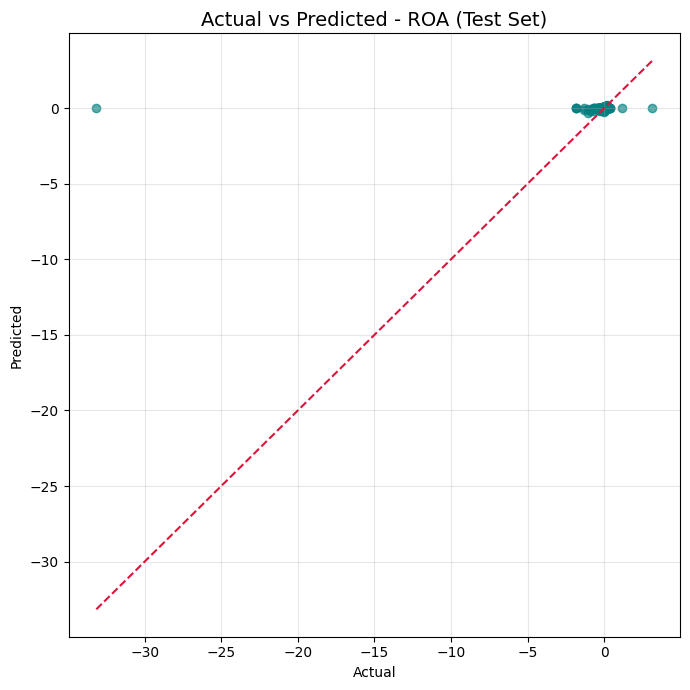

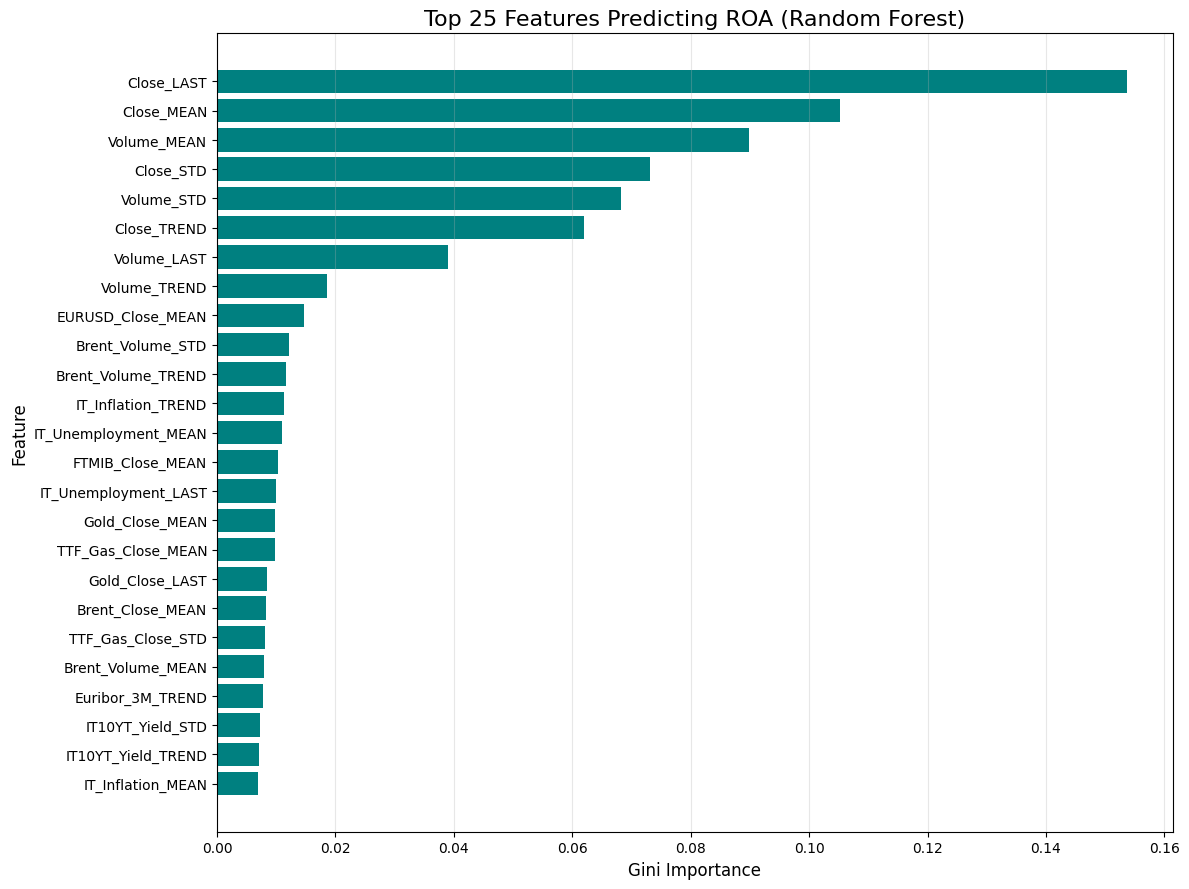

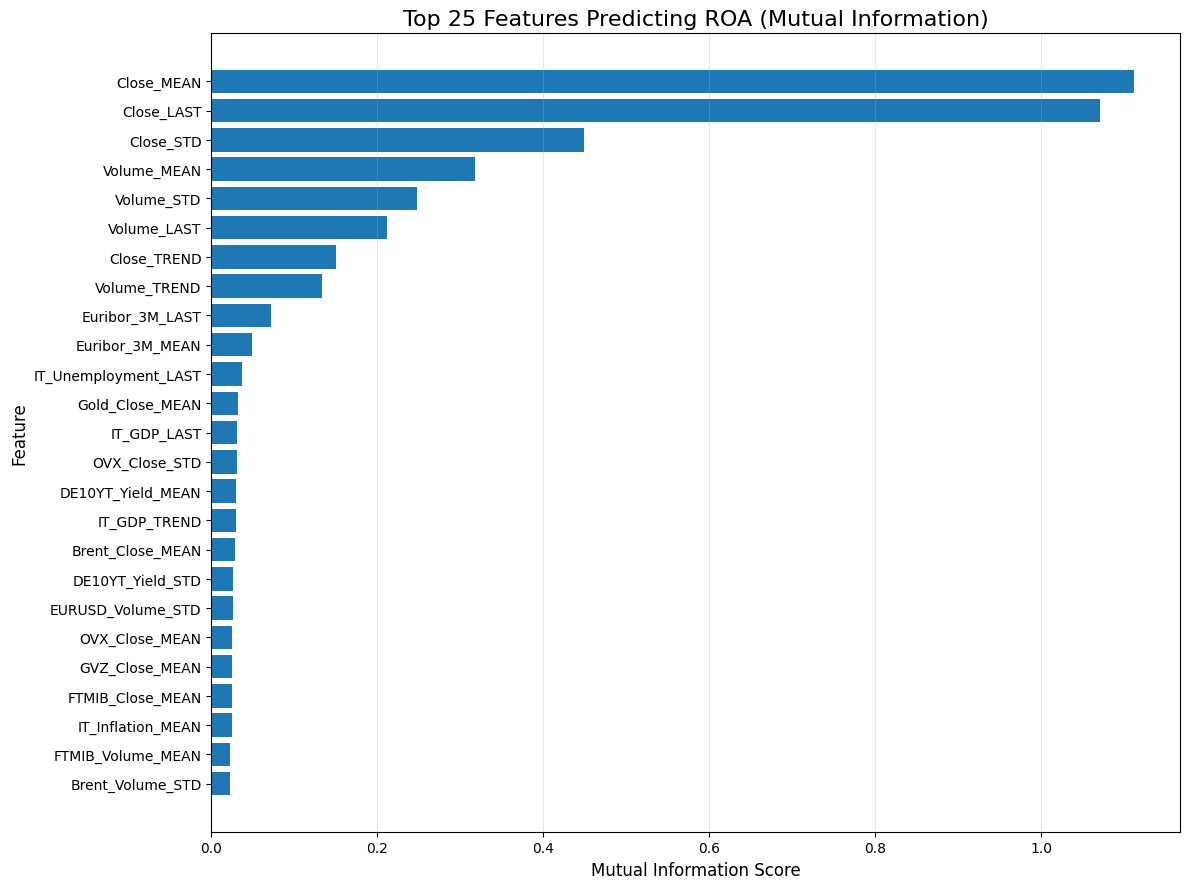

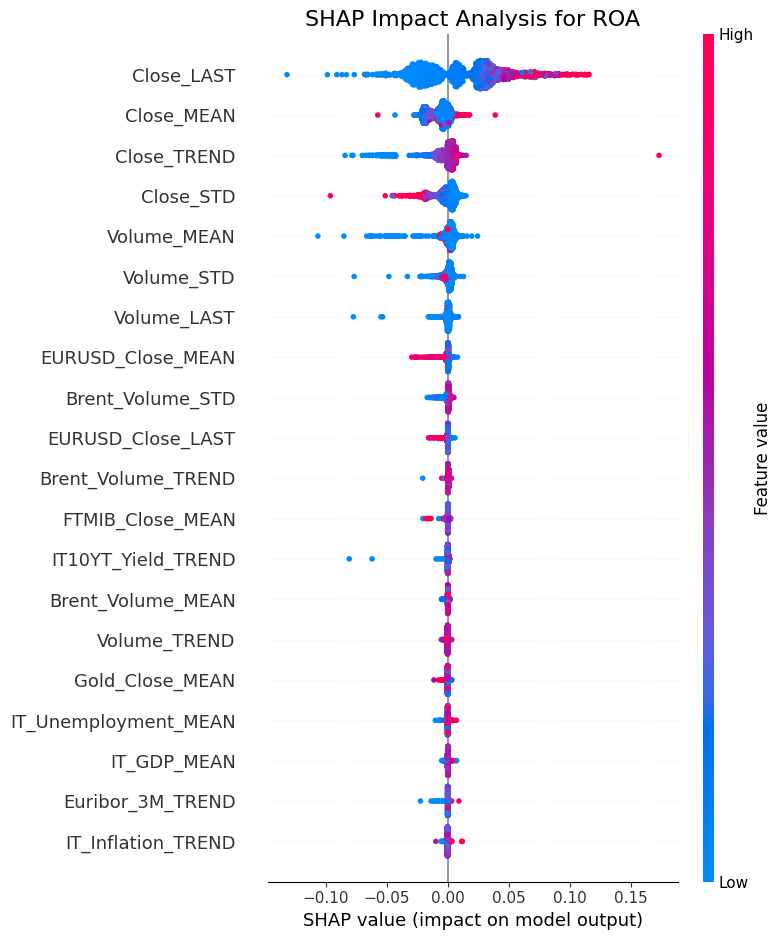


                              Net_Income                              
Total valid 90-day windows extracted: 8980

Top 10 features by Mutual Information:
        Feature  MI_Regression
     Close_MEAN       1.141305
     Close_LAST       1.103124
    Volume_MEAN       0.586382
    Volume_LAST       0.497846
      Close_STD       0.462961
     Volume_STD       0.450406
   Volume_TREND       0.232342
    Close_TREND       0.157687
Euribor_3M_LAST       0.098491
Euribor_3M_MEAN       0.074598


/Users/davide/UniPD/Tesi/xLSTM/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/davide/UniPD/Tesi/xLSTM/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Model comparison (test metrics):
Raw Target RF  -> R2: 0.2675 | MAE: 210098.9329 | RMSE: 922716.3121 | Avg % Diff: 1106.62% | WAPE: 69.55% | sMAPE: 101.69%
Signed-Log RF  -> R2: 0.1471 | MAE: 241509.5491 | RMSE: 995686.4998 | Avg % Diff: 132.76% | WAPE: 79.94% | sMAPE: 130.64%

Selected model for Net_Income: Raw-Target RF (selected)
Best RF Params for Net_Income: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 32, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 129831.5395 | RMSE: 563852.1511 | R2: 0.7923 | Avg % Diff: 525.63% | Median % Diff: 46.21% | WAPE: 39.02% | sMAPE: 72.19%
Test  -> MAE: 210098.9329 | RMSE: 922716.3121 | R2: 0.2675 | Avg % Diff: 1106.62% | Median % Diff: 78.23% | WAPE: 69.55% | sMAPE: 101.69%


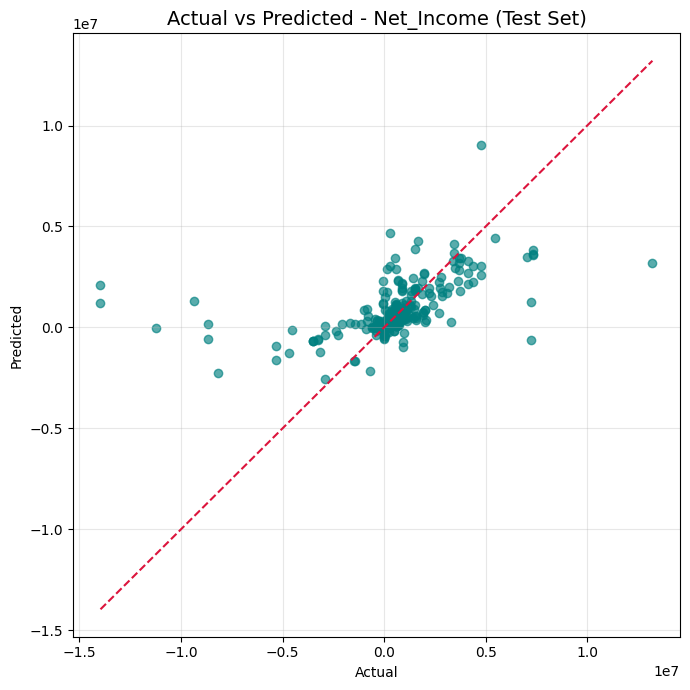

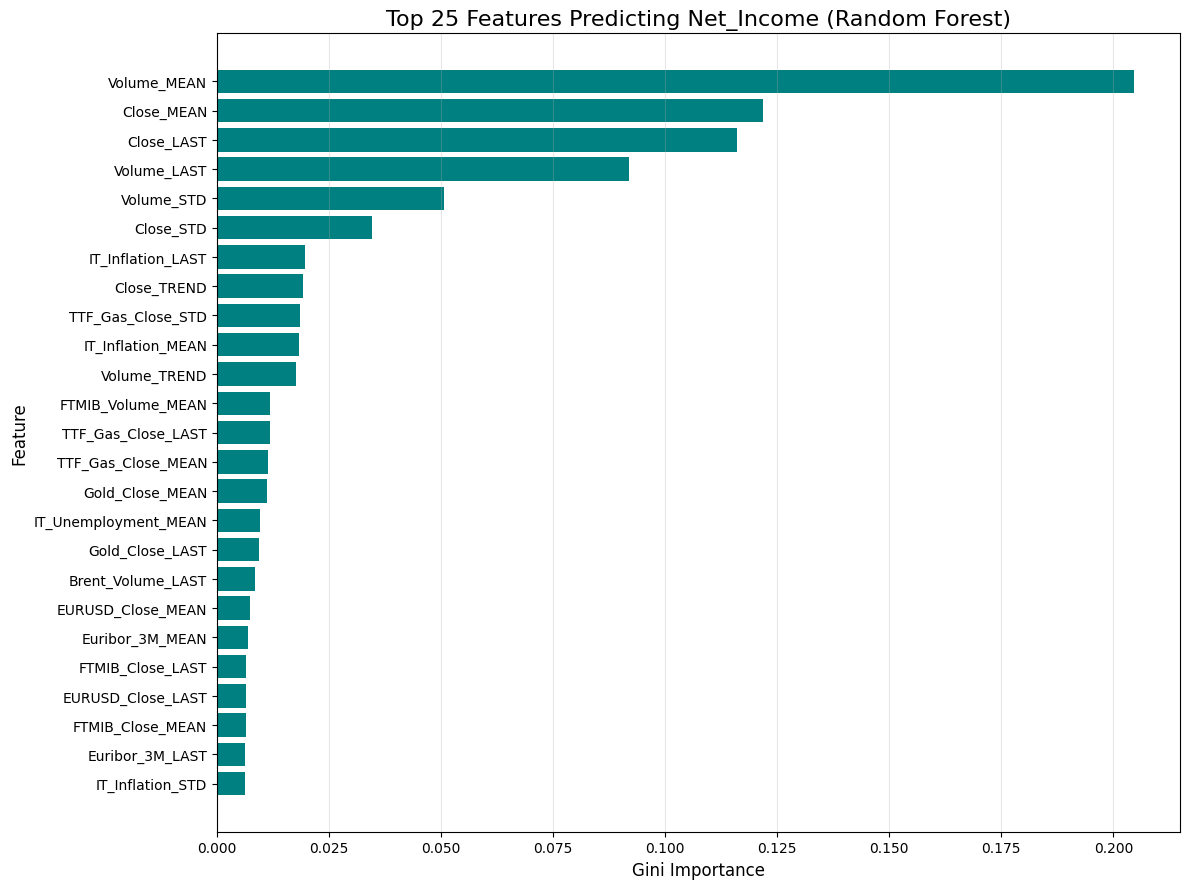

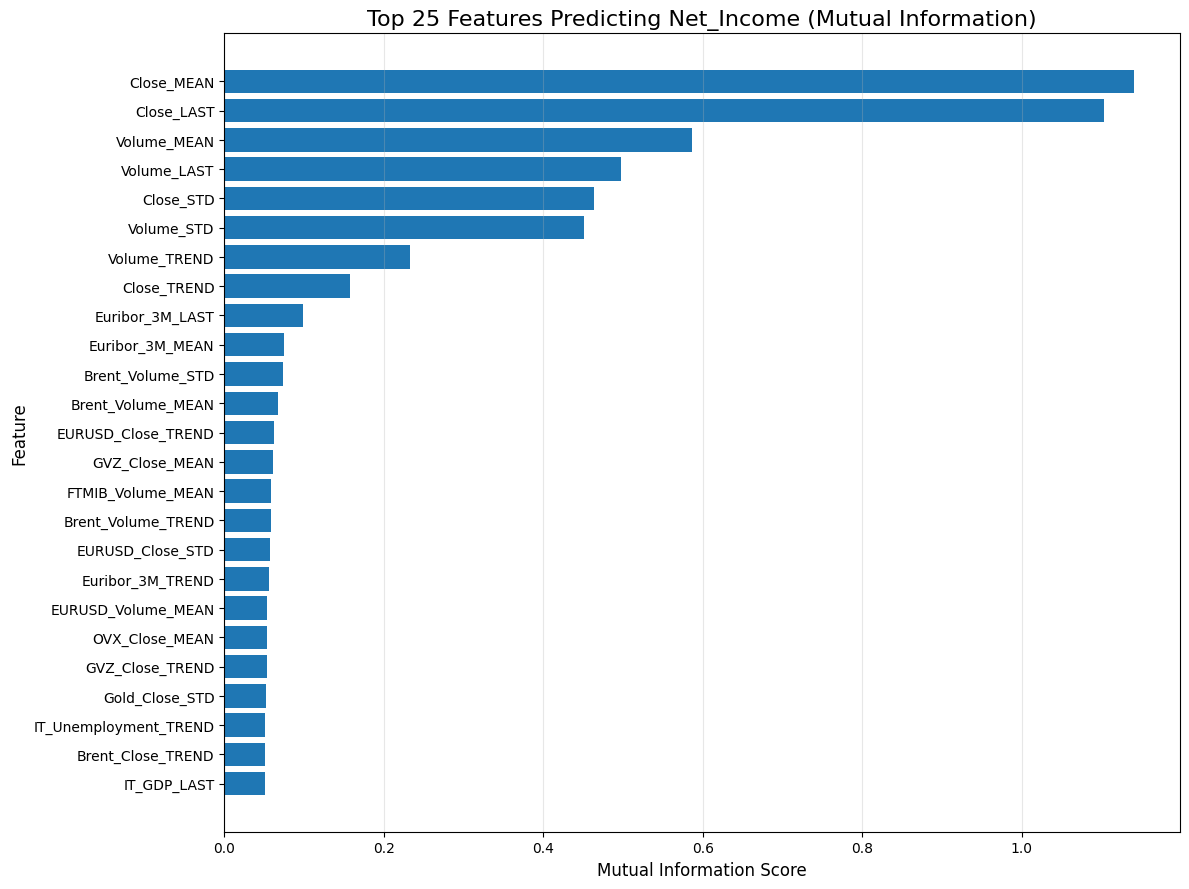

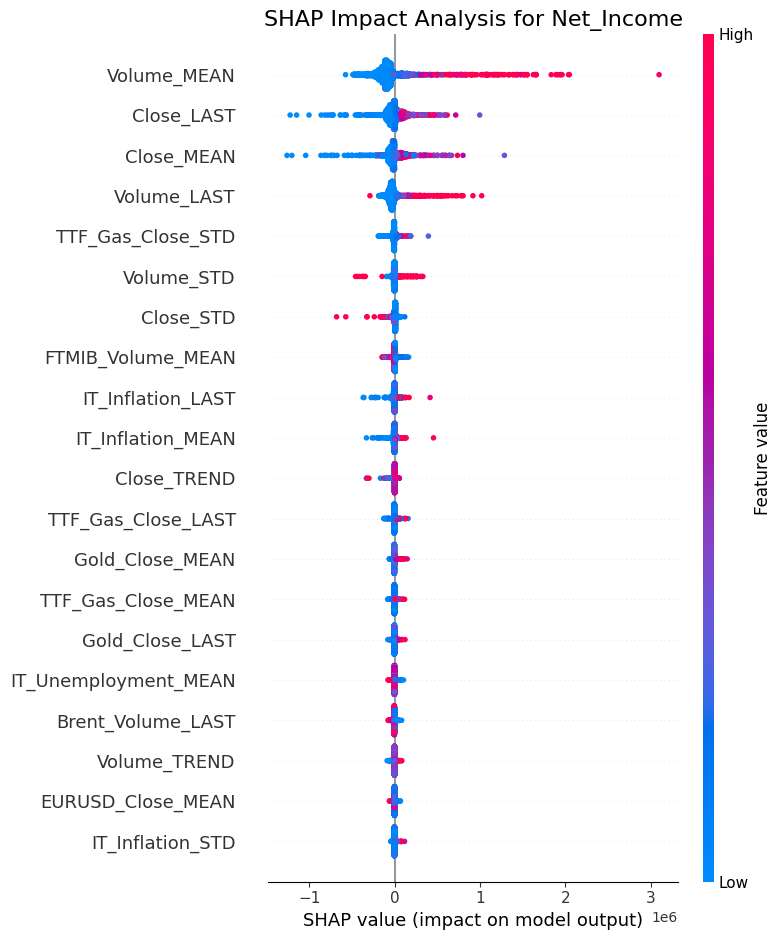


Final Test Performance Summary (selected model per target)
    Target           Selected_Model  Test_R2    Test_RMSE      Test_MAE  AvgPctDiff_%  MedianPctDiff_%    WAPE_%    sMAPE_%
    EBITDA Raw-Target RF (selected) 0.737571 1.350049e+06 343433.395558    620.706977        54.986346 45.180092  78.207627
       ROA Signed-Log RF (selected) 0.005398 7.954334e-01      0.071699    198.460534        80.624432 86.817511 108.828766
Net_Income Raw-Target RF (selected) 0.267541 9.227163e+05 210098.932930   1106.622761        78.229838 69.545549 101.688538


In [10]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df.groupby('Company')}

for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            start_date = target_date - pd.Timedelta(days=90)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 40:
                continue

            window_stats = {'Company': company}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    window_stats[f"{feat}_MEAN"] = 0.0
                    window_stats[f"{feat}_STD"] = 0.0
                    window_stats[f"{feat}_LAST"] = 0.0
                    window_stats[f"{feat}_TREND"] = 0.0
                else:
                    values = series.values.astype(float)
                    window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                    window_stats[f"{feat}_STD"] = float(np.std(values))
                    window_stats[f"{feat}_LAST"] = float(values[-1])

                    if len(values) > 1:
                        x_axis = np.arange(len(values), dtype=float)
                        slope = np.polyfit(x_axis, values, deg=1)[0]
                    else:
                        slope = 0.0
                    window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 90-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    X_df = X_df.drop(columns=['Company']).fillna(0.0)

    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42
    )

    mi_df, mi_col = compute_mutual_information(X_train, y_train.values, task='regression')
    print("\nTop 10 features by Mutual Information:")
    print(mi_df.head(10).to_string(index=False))

    # Model A: raw target
    rf_raw, params_raw = fit_rf(X_train, y_train.values)
    y_train_pred_raw = rf_raw.predict(X_train)
    y_test_pred_raw = rf_raw.predict(X_test)
    train_raw = regression_metrics(y_train.values, y_train_pred_raw)
    test_raw = regression_metrics(y_test.values, y_test_pred_raw)

    # Model B: signed-log target
    y_train_log = signed_log_transform(y_train.values)
    rf_log, params_log = fit_rf(X_train, y_train_log)
    y_train_pred_log = signed_log_inverse(rf_log.predict(X_train))
    y_test_pred_log = signed_log_inverse(rf_log.predict(X_test))
    train_log = regression_metrics(y_train.values, y_train_pred_log)
    test_log = regression_metrics(y_test.values, y_test_pred_log)

    # Select model by weighted absolute percentage error for robustness
    use_log_model = test_log['WAPE'] < test_raw['WAPE']

    if use_log_model:
        rf = rf_log
        model_label = 'Signed-Log RF (selected)'
        y_train_pred = y_train_pred_log
        y_test_pred = y_test_pred_log
        best_params = params_log
        train_metrics = train_log
        test_metrics = test_log
    else:
        rf = rf_raw
        model_label = 'Raw-Target RF (selected)'
        y_train_pred = y_train_pred_raw
        y_test_pred = y_test_pred_raw
        best_params = params_raw
        train_metrics = train_raw
        test_metrics = test_raw

    print("\nModel comparison (test metrics):")
    print(f"Raw Target RF  -> R2: {test_raw['R2']:.4f} | MAE: {test_raw['MAE']:.4f} | RMSE: {test_raw['RMSE']:.4f} | Avg % Diff: {test_raw['AvgPctDiff']:.2f}% | WAPE: {test_raw['WAPE']:.2f}% | sMAPE: {test_raw['sMAPE']:.2f}%")
    print(f"Signed-Log RF  -> R2: {test_log['R2']:.4f} | MAE: {test_log['MAE']:.4f} | RMSE: {test_log['RMSE']:.4f} | Avg % Diff: {test_log['AvgPctDiff']:.2f}% | WAPE: {test_log['WAPE']:.2f}% | sMAPE: {test_log['sMAPE']:.2f}%")

    print(f"\nSelected model for {target}: {model_label}")
    print(f"Best RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Selected_Model': model_label,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    # Scatter Plot: Actual vs Predicted
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_test_pred, alpha=0.65, color='teal')
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='crimson', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {target} (Test Set)', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Gini Importance
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Mutual Information
    top_mi = mi_df.head(25).sort_values(by=mi_col, ascending=True)
    plt.figure(figsize=(12, 9))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 25 Features Predicting {target} (Mutual Information)', fontsize=16)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (selected model per target)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

### YoY: Exogenous Variables Only


                                EBITDA                                
Total valid 365-day windows extracted: 2138

Top 10 features by Mutual Information:
            Feature  MI_Regression
        Volume_MEAN       0.420202
        Volume_LAST       0.377097
         Volume_STD       0.360646
       Volume_TREND       0.216725
 EURUSD_Close_TREND       0.097577
 Brent_Volume_TREND       0.096023
  FTMIB_Close_TREND       0.094580
   FTMIB_Volume_STD       0.090196
  Brent_Close_TREND       0.089855
EURUSD_Volume_TREND       0.084595

Model comparison (test metrics):
Raw Target RF  -> R2: 0.5957 | MAE: 452025.5783 | RMSE: 1828890.6692 | Avg % Diff: 977.28% | WAPE: 57.00% | sMAPE: 84.69%
Signed-Log RF  -> R2: 0.1806 | MAE: 634132.6652 | RMSE: 2603468.6645 | Avg % Diff: 309.17% | WAPE: 79.97% | sMAPE: 103.61%

Selected model for EBITDA: Raw-Target RF (selected)
Best RF Params for EBITDA: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth

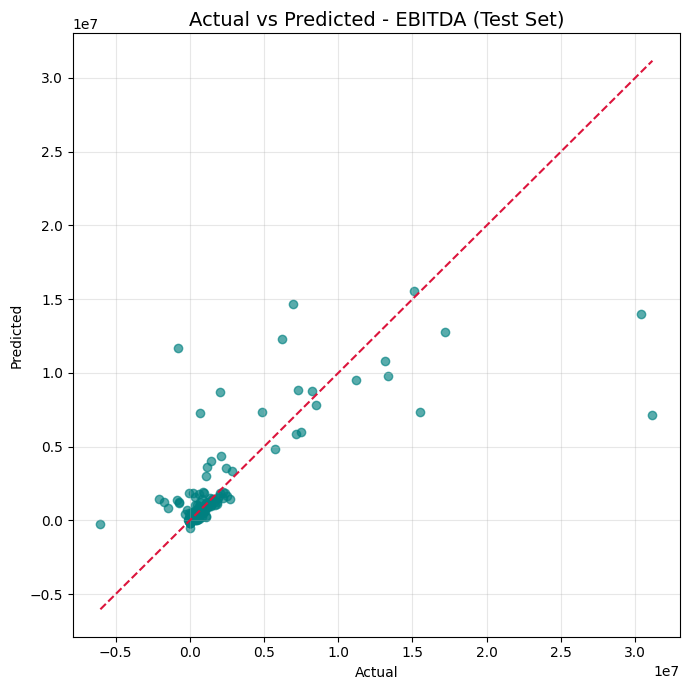

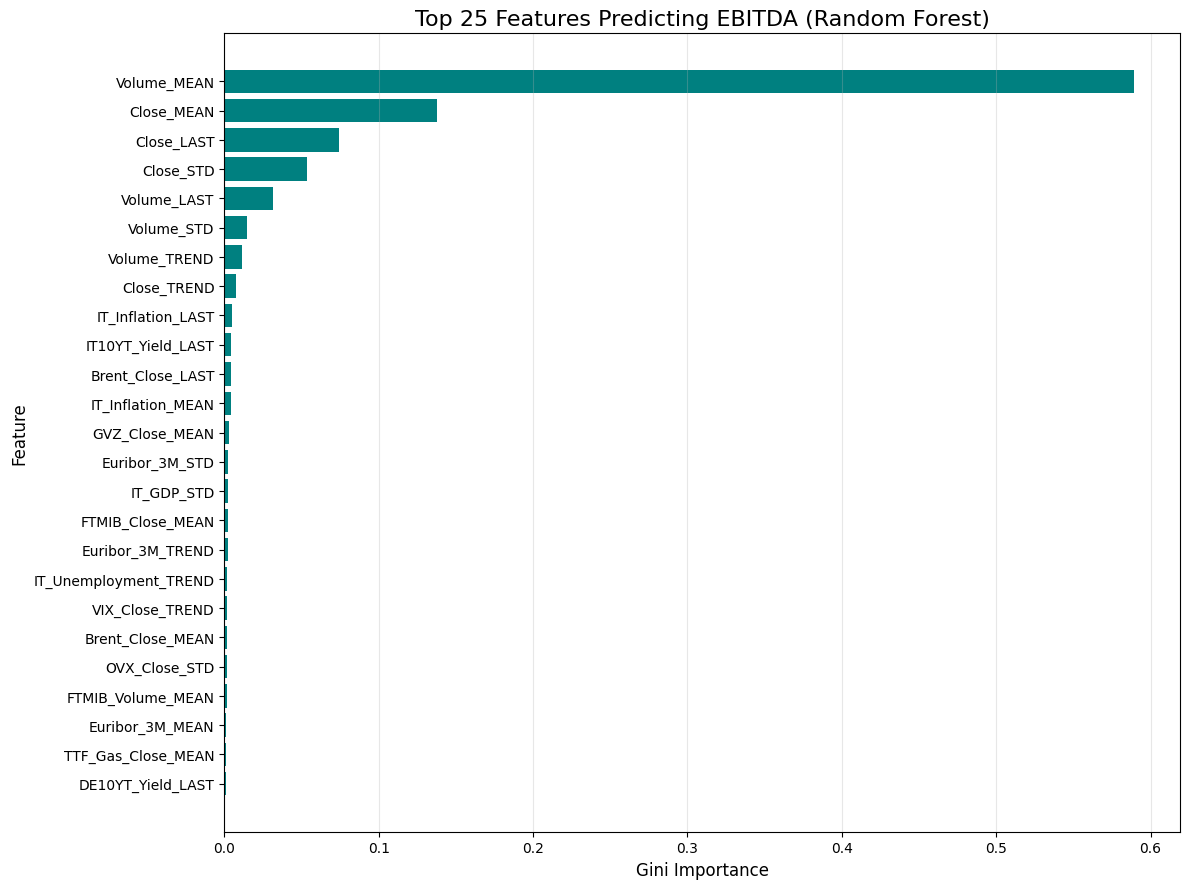

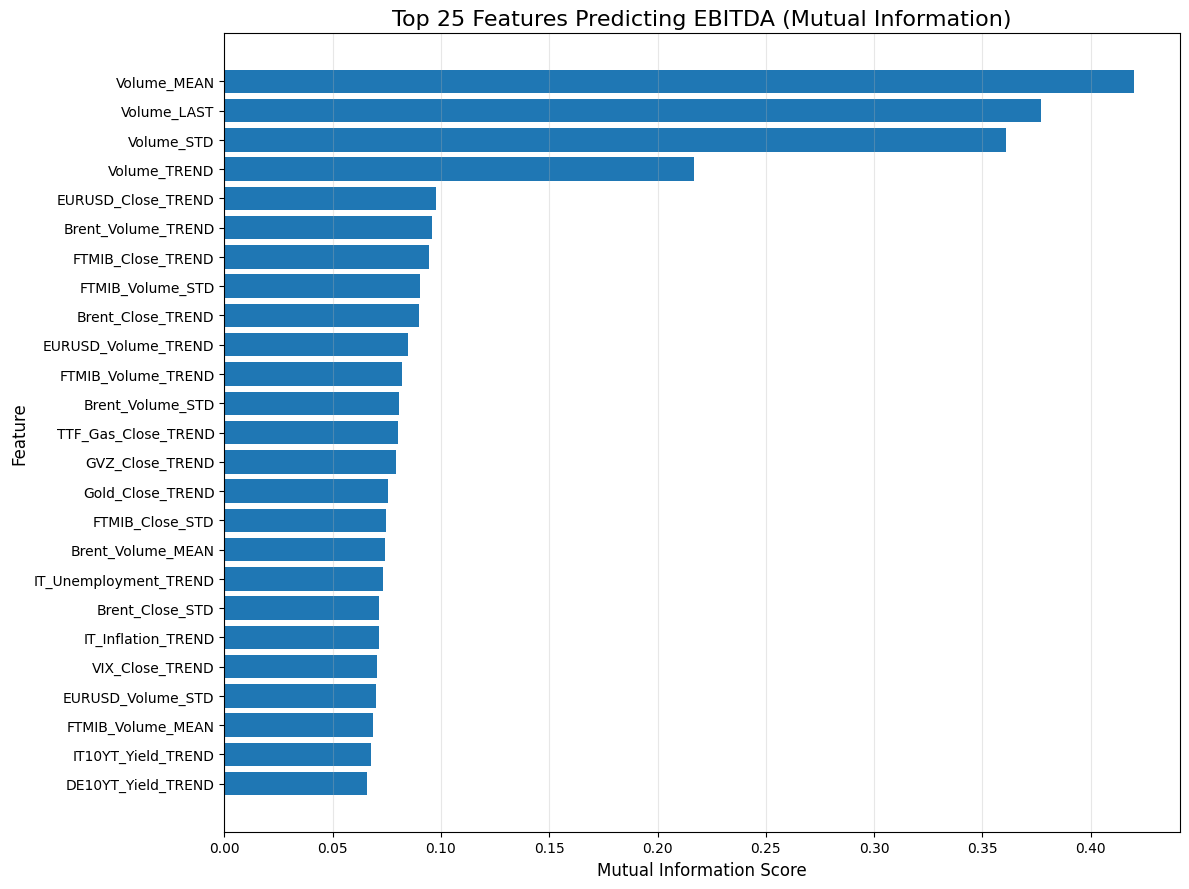

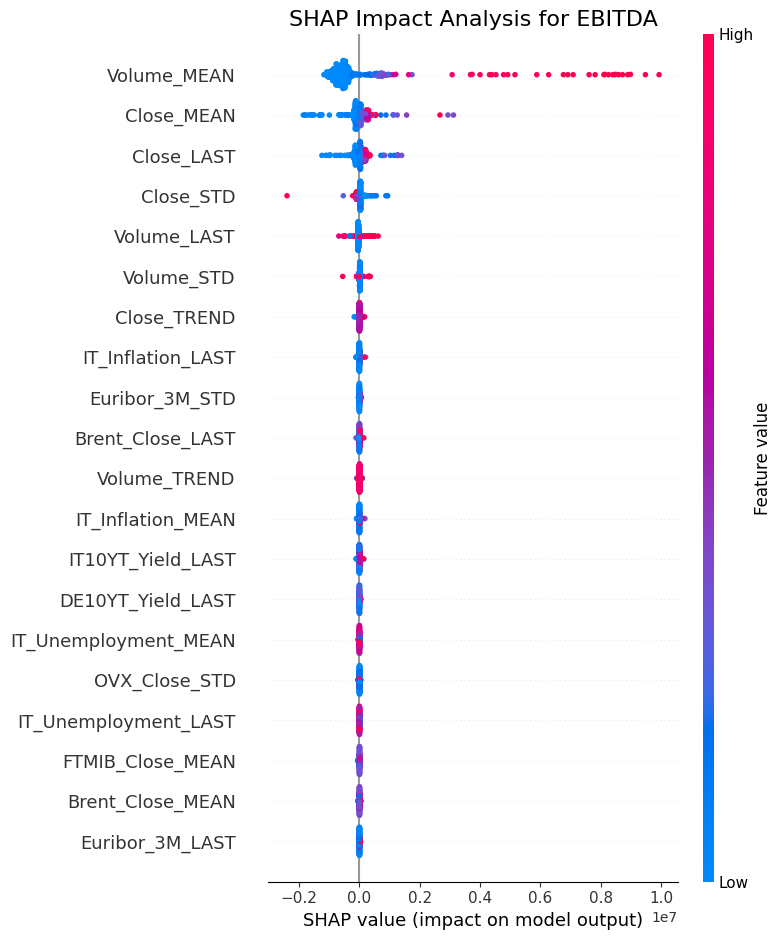


                                 ROA                                  
Total valid 365-day windows extracted: 2173

Top 10 features by Mutual Information:
            Feature  MI_Regression
       Volume_TREND       0.067462
        Volume_MEAN       0.060468
     GVZ_Close_MEAN       0.054314
   Gold_Close_TREND       0.051139
         Volume_STD       0.050875
    Gold_Close_MEAN       0.049894
  FTMIB_Volume_MEAN       0.047474
   DE10YT_Yield_STD       0.046036
   IT_Inflation_STD       0.045667
IT_Unemployment_STD       0.044754

Model comparison (test metrics):
Raw Target RF  -> R2: -0.0356 | MAE: 0.1400 | RMSE: 1.4653 | Avg % Diff: 415.86% | WAPE: 97.49% | sMAPE: 110.76%
Signed-Log RF  -> R2: -0.0259 | MAE: 0.1373 | RMSE: 1.4584 | Avg % Diff: 388.01% | WAPE: 95.59% | sMAPE: 110.37%

Selected model for ROA: Signed-Log RF (selected)
Best RF Params for ROA: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'criterion': 'abs

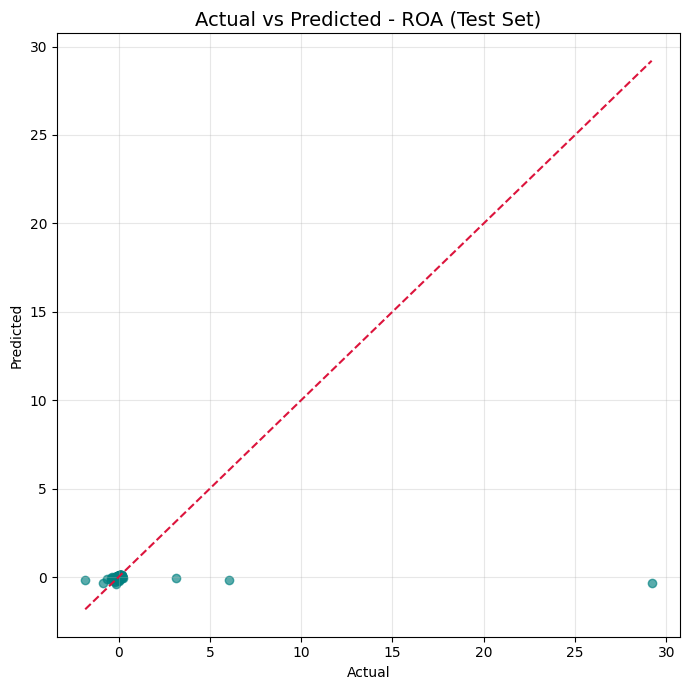

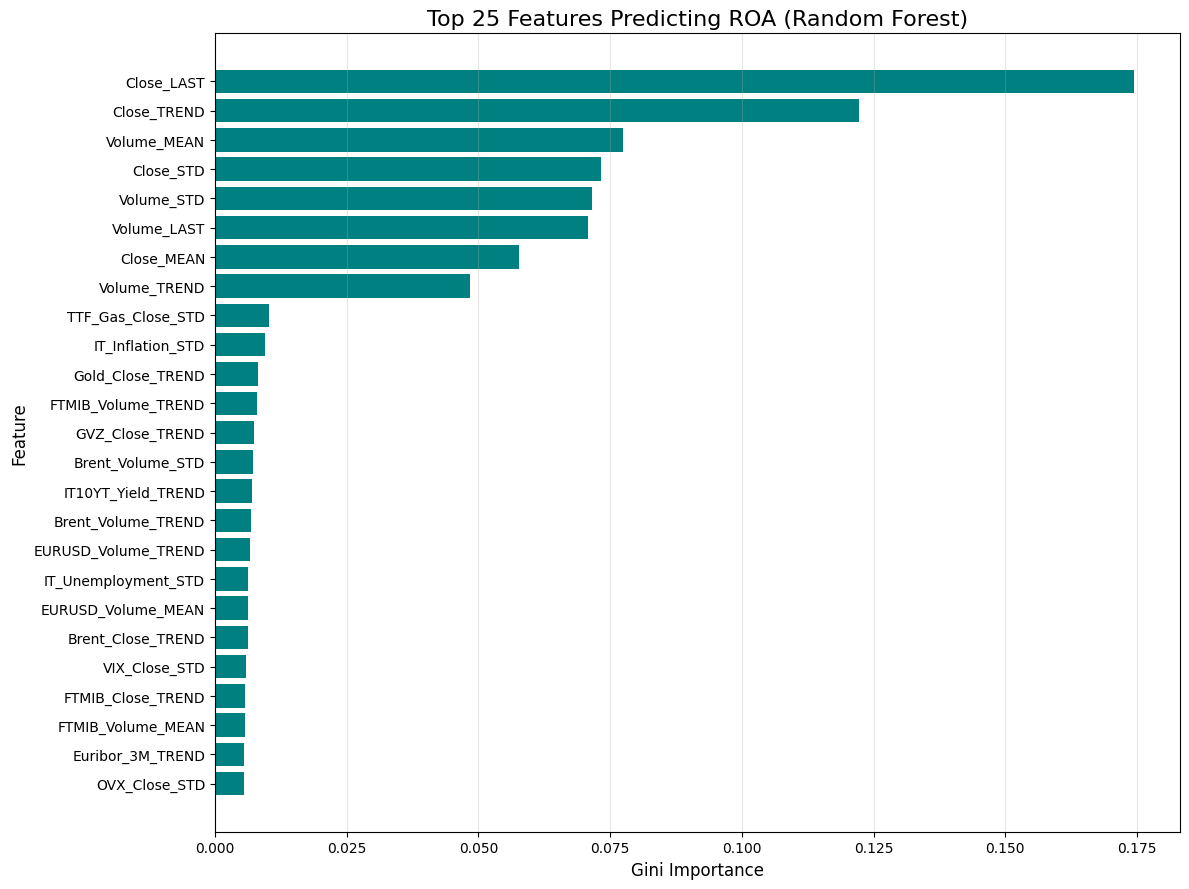

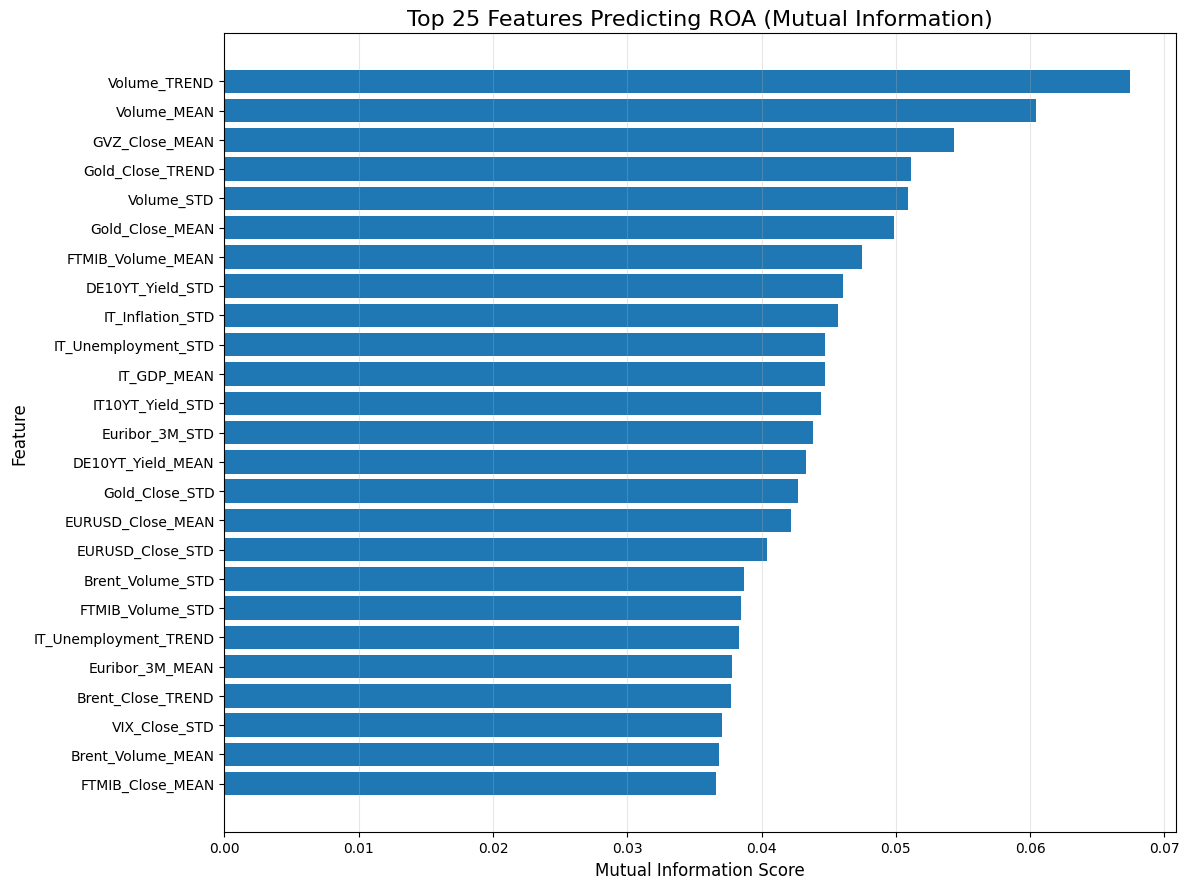

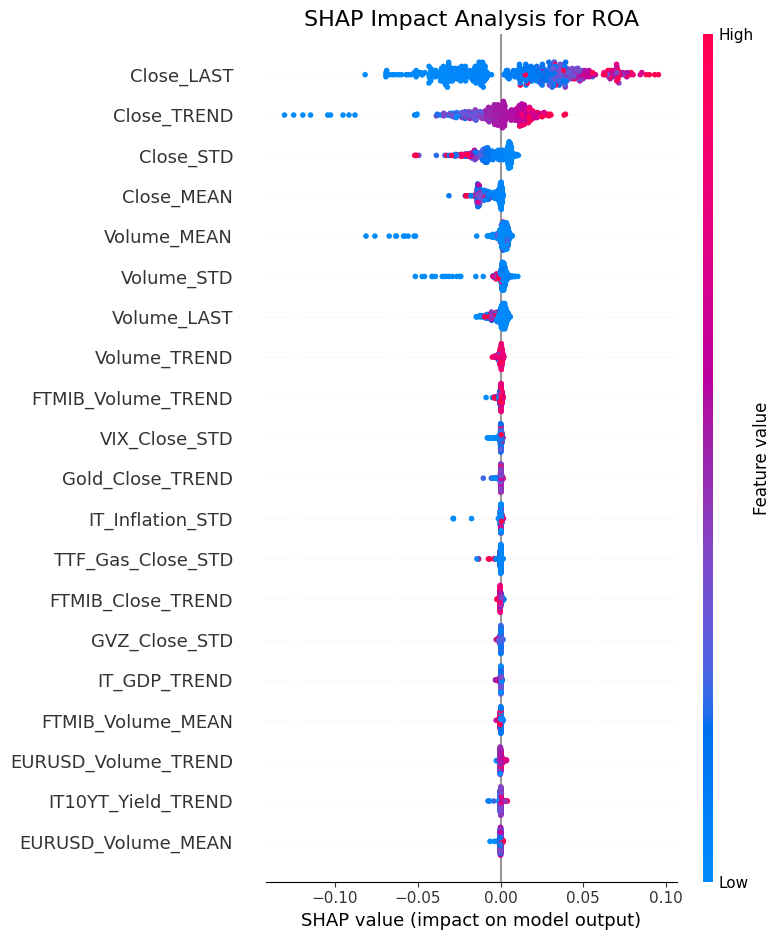


                              Net_Income                              
Total valid 365-day windows extracted: 2175

Top 10 features by Mutual Information:
              Feature  MI_Regression
          Volume_MEAN       0.360672
          Volume_LAST       0.275156
           Volume_STD       0.252750
    FTMIB_Close_TREND       0.110500
IT_Unemployment_TREND       0.107056
   EURUSD_Close_TREND       0.105616
         Volume_TREND       0.105527
    Brent_Close_TREND       0.105269
     FTMIB_Volume_STD       0.104020
   Brent_Volume_TREND       0.100350

Model comparison (test metrics):
Raw Target RF  -> R2: 0.2881 | MAE: 207979.5587 | RMSE: 671868.2460 | Avg % Diff: 362.38% | WAPE: 75.57% | sMAPE: 104.74%
Signed-Log RF  -> R2: 0.1338 | MAE: 231287.2171 | RMSE: 741073.3655 | Avg % Diff: 118.33% | WAPE: 84.03% | sMAPE: 141.12%

Selected model for Net_Income: Raw-Target RF (selected)
Best RF Params for Net_Income: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 2, 'm

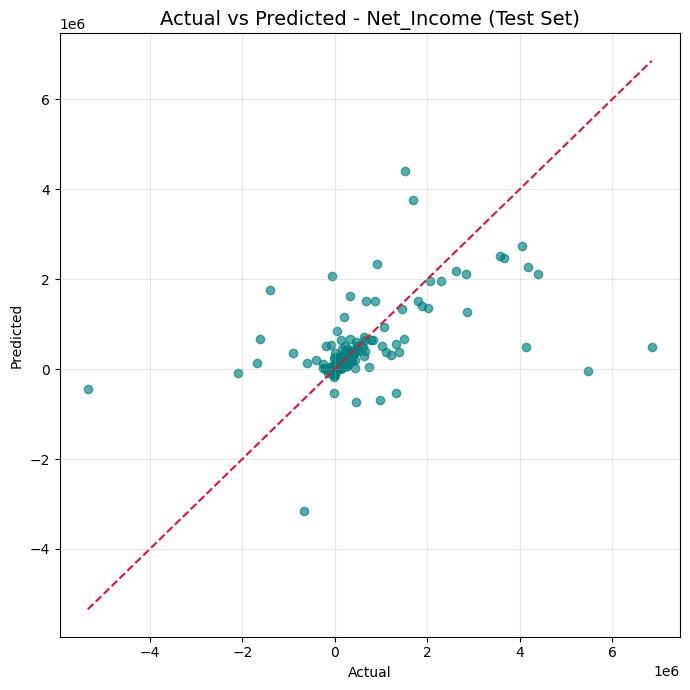

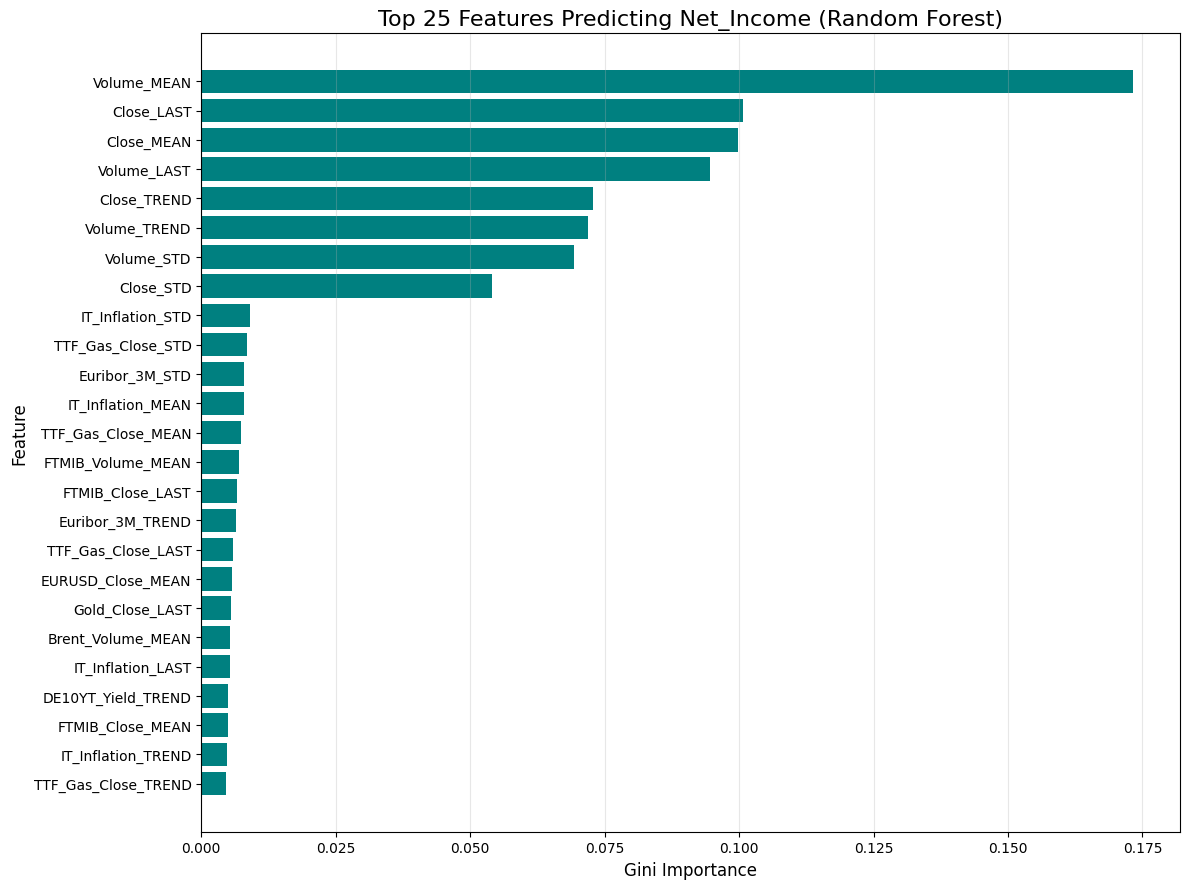

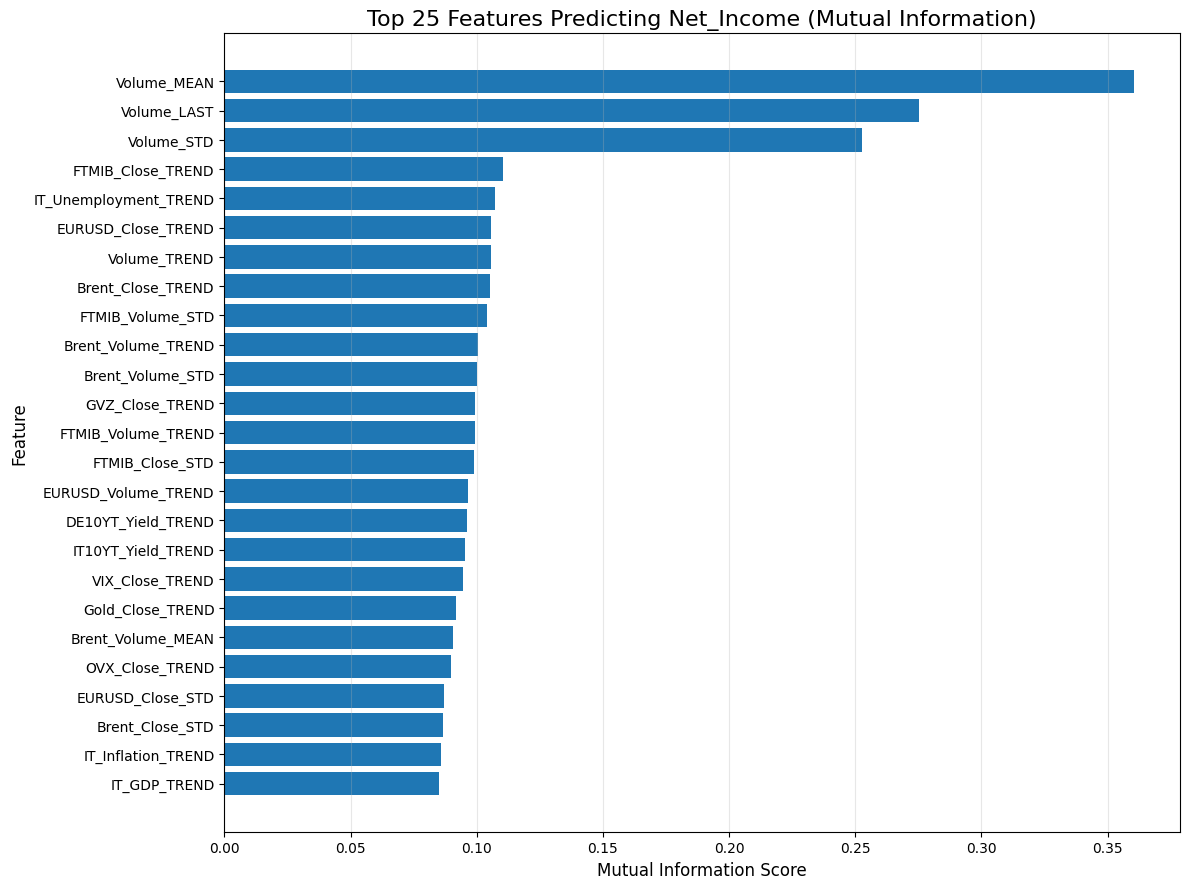

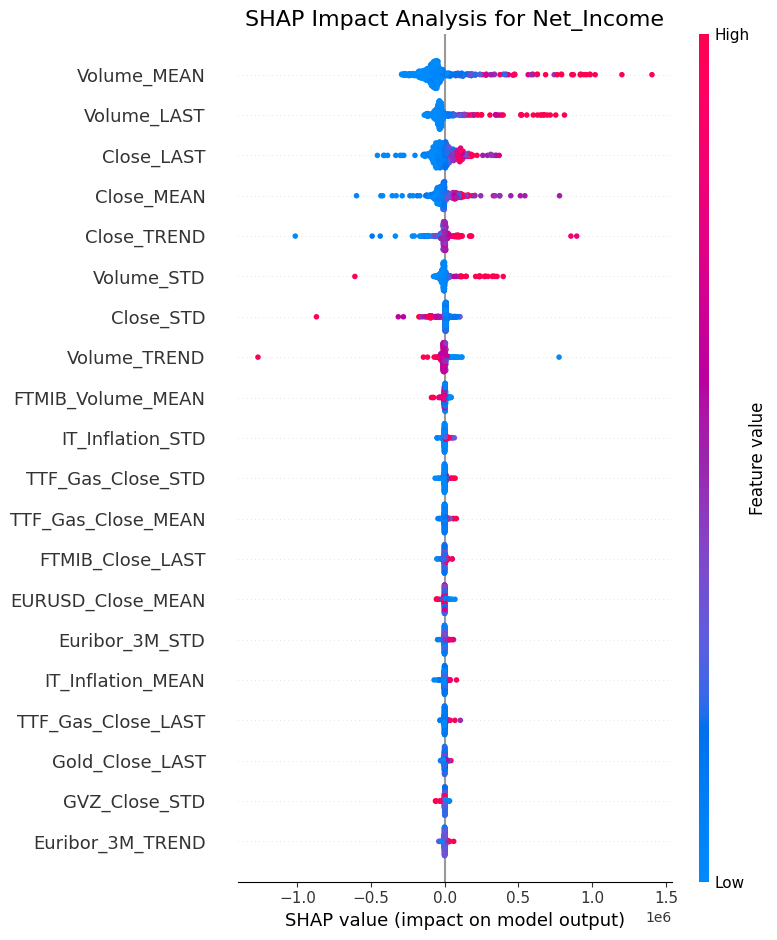


Final Test Performance Summary (selected model per target)
    Target           Selected_Model   Test_R2    Test_RMSE      Test_MAE  AvgPctDiff_%  MedianPctDiff_%    WAPE_%    sMAPE_%
    EBITDA Raw-Target RF (selected)  0.595650 1.828891e+06 452025.578298    977.278476        71.455253 57.003694  84.687612
       ROA Signed-Log RF (selected) -0.025924 1.458431e+00      0.137307    388.006698        88.968389 95.590061 110.373180
Net_Income Raw-Target RF (selected)  0.288059 6.718682e+05 207979.558683    362.375032        82.298403 75.565159 104.736133


In [11]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 200:
                continue

            window_stats = {'Company': company}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    window_stats[f"{feat}_MEAN"] = 0.0
                    window_stats[f"{feat}_STD"] = 0.0
                    window_stats[f"{feat}_LAST"] = 0.0
                    window_stats[f"{feat}_TREND"] = 0.0
                else:
                    values = series.values.astype(float)
                    window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                    window_stats[f"{feat}_STD"] = float(np.std(values))
                    window_stats[f"{feat}_LAST"] = float(values[-1])

                    if len(values) > 1:
                        x_axis = np.arange(len(values), dtype=float)
                        slope = np.polyfit(x_axis, values, deg=1)[0]
                    else:
                        slope = 0.0
                    window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 365-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    X_df = X_df.drop(columns=['Company']).fillna(0.0)

    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42
    )

    mi_df, mi_col = compute_mutual_information(X_train, y_train.values, task='regression')
    print("\nTop 10 features by Mutual Information:")
    print(mi_df.head(10).to_string(index=False))

    # Model A: raw target
    rf_raw, params_raw = fit_rf(X_train, y_train.values)
    y_train_pred_raw = rf_raw.predict(X_train)
    y_test_pred_raw = rf_raw.predict(X_test)
    train_raw = regression_metrics(y_train.values, y_train_pred_raw)
    test_raw = regression_metrics(y_test.values, y_test_pred_raw)

    # Model B: signed-log target
    y_train_log = signed_log_transform(y_train.values)
    rf_log, params_log = fit_rf(X_train, y_train_log)
    y_train_pred_log = signed_log_inverse(rf_log.predict(X_train))
    y_test_pred_log = signed_log_inverse(rf_log.predict(X_test))
    train_log = regression_metrics(y_train.values, y_train_pred_log)
    test_log = regression_metrics(y_test.values, y_test_pred_log)

    # Select model by weighted absolute percentage error for robustness
    use_log_model = test_log['WAPE'] < test_raw['WAPE']

    if use_log_model:
        rf = rf_log
        model_label = 'Signed-Log RF (selected)'
        y_train_pred = y_train_pred_log
        y_test_pred = y_test_pred_log
        best_params = params_log
        train_metrics = train_log
        test_metrics = test_log
    else:
        rf = rf_raw
        model_label = 'Raw-Target RF (selected)'
        y_train_pred = y_train_pred_raw
        y_test_pred = y_test_pred_raw
        best_params = params_raw
        train_metrics = train_raw
        test_metrics = test_raw

    print("\nModel comparison (test metrics):")
    print(f"Raw Target RF  -> R2: {test_raw['R2']:.4f} | MAE: {test_raw['MAE']:.4f} | RMSE: {test_raw['RMSE']:.4f} | Avg % Diff: {test_raw['AvgPctDiff']:.2f}% | WAPE: {test_raw['WAPE']:.2f}% | sMAPE: {test_raw['sMAPE']:.2f}%")
    print(f"Signed-Log RF  -> R2: {test_log['R2']:.4f} | MAE: {test_log['MAE']:.4f} | RMSE: {test_log['RMSE']:.4f} | Avg % Diff: {test_log['AvgPctDiff']:.2f}% | WAPE: {test_log['WAPE']:.2f}% | sMAPE: {test_log['sMAPE']:.2f}%")

    print(f"\nSelected model for {target}: {model_label}")
    print(f"Best RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Selected_Model': model_label,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    # Scatter Plot: Actual vs Predicted
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, y_test_pred, alpha=0.65, color='teal')
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='crimson', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {target} (Test Set)', fontsize=14)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Gini Importance
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bar Plot: Mutual Information
    top_mi = mi_df.head(25).sort_values(by=mi_col, ascending=True)
    plt.figure(figsize=(12, 9))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 25 Features Predicting {target} (Mutual Information)', fontsize=16)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (selected model per target)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

## Part 2: YoY Log-Returns Target Analysis



                           EBITDA_LogReturn                           
Total valid 365-day windows extracted: 2126

Top 10 features by Mutual Information:
            Feature  MI_Regression
  EURUSD_Close_MEAN       0.084300
   DE10YT_Yield_STD       0.084287
   Brent_Volume_STD       0.078486
   FTMIB_Close_MEAN       0.074644
    FTMIB_Close_STD       0.072016
TTF_Gas_Close_TREND       0.071258
   Brent_Close_MEAN       0.071146
   FTMIB_Close_LAST       0.071113
    OVX_Close_TREND       0.070179
     Gold_Close_STD       0.068735

Best RF Params for EBITDA_LogReturn: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 2.0394 | RMSE: 5.6982 | R2: 0.1118 | Avg % Diff: 473841.00% | Median % Diff: 94.03% | WAPE: 93.84% | sMAPE: 136.15%
Test  -> MAE: 2.3881 | RMSE: 6.5013 | R2: -0.0136 | Avg % Diff: 242.23% | Median % Diff: 95.55% | WAPE: 104.14% | sMAPE: 133.29%


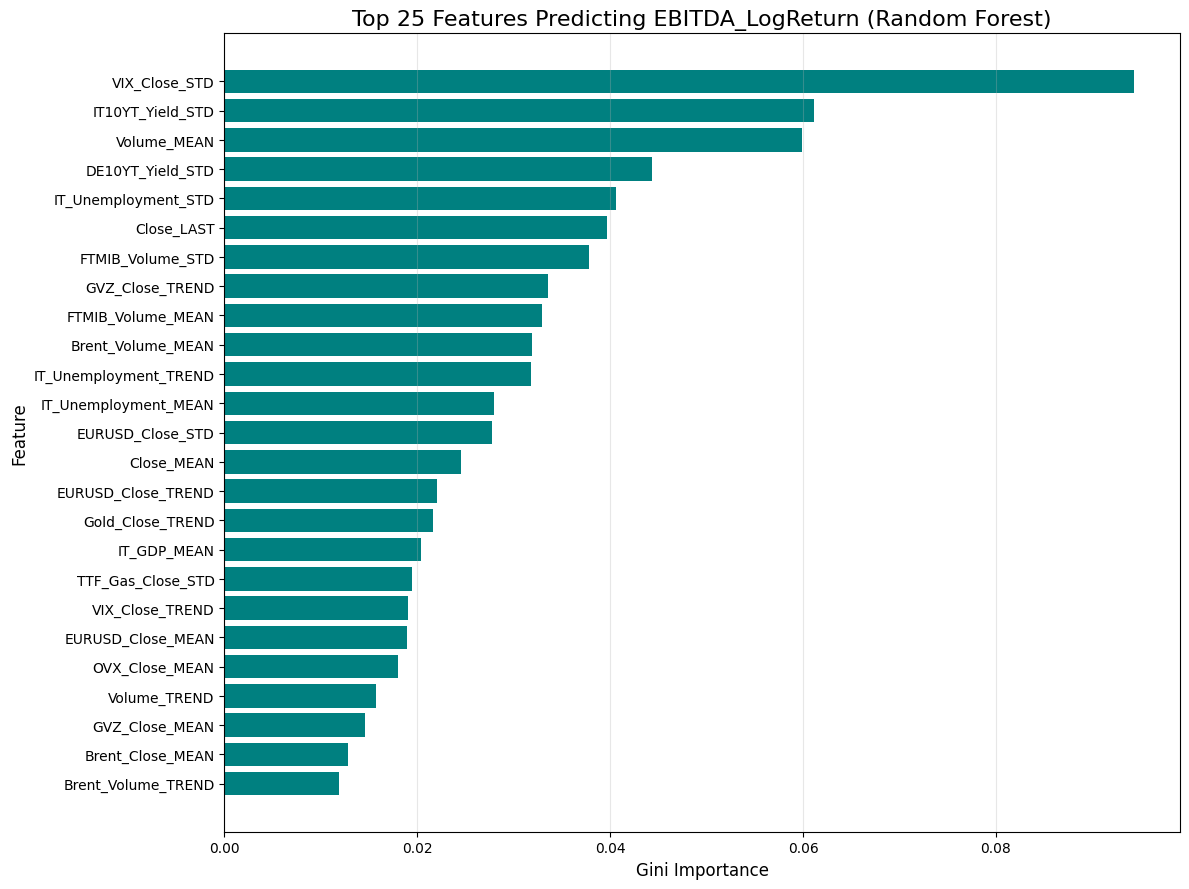

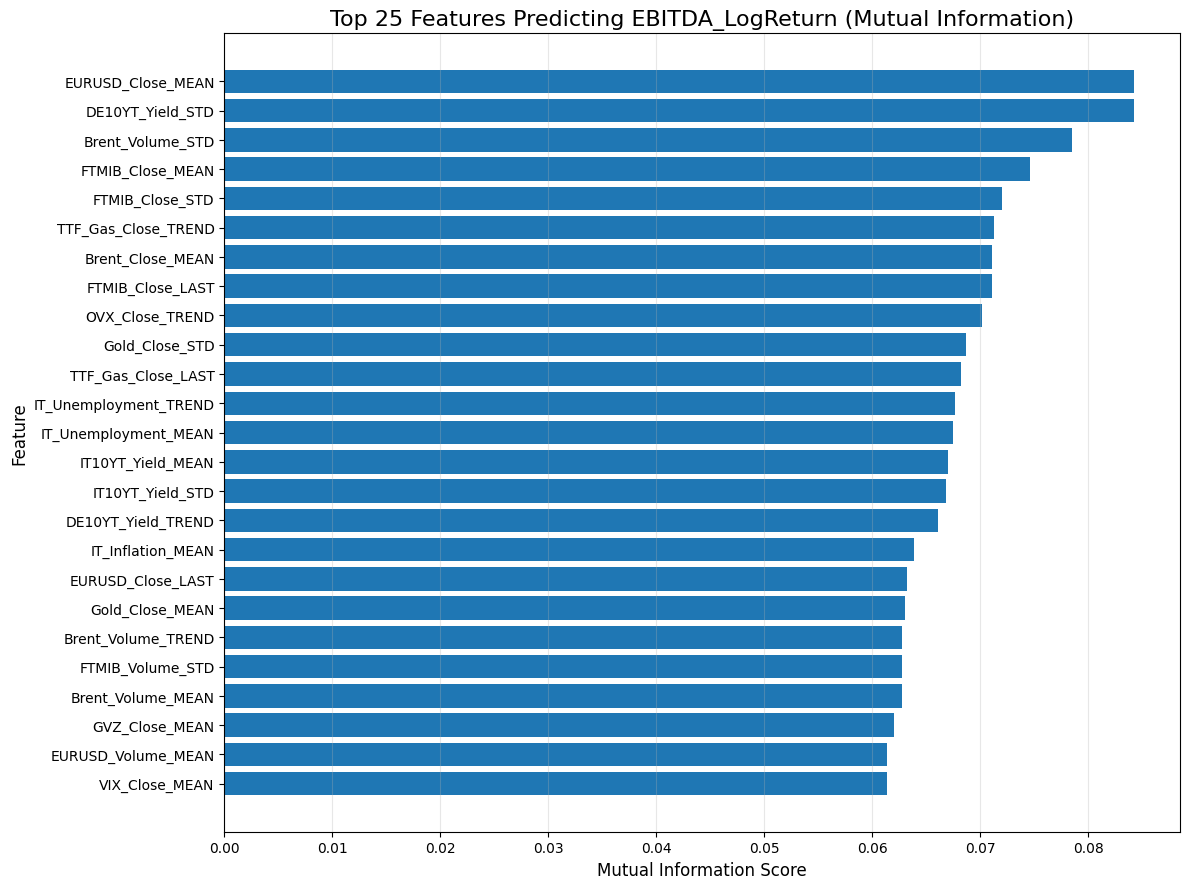

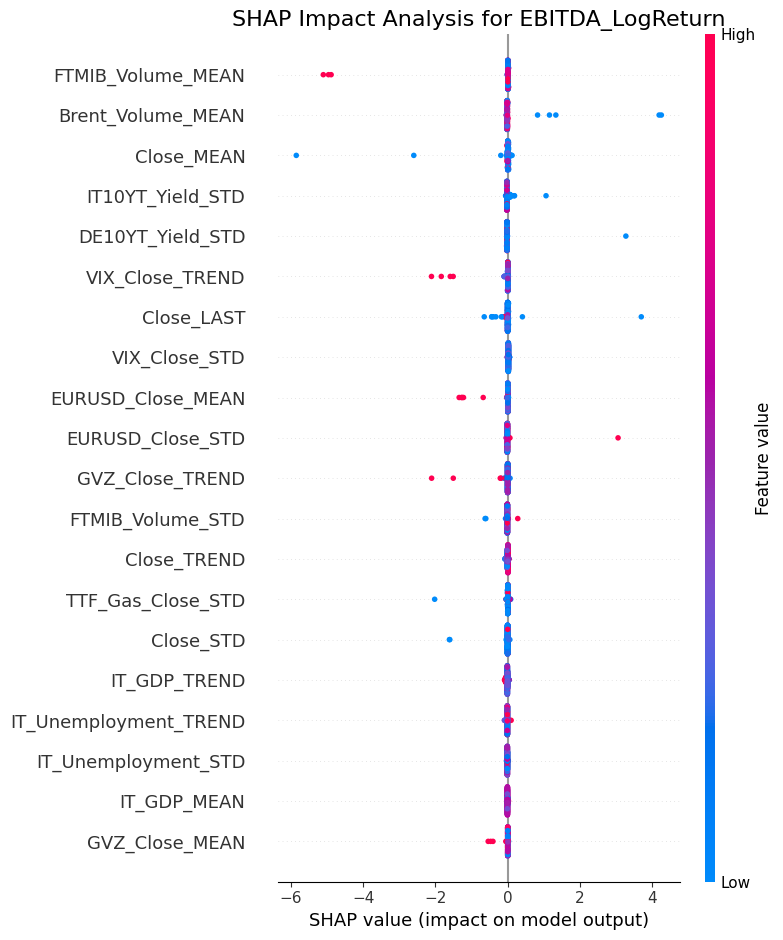


                            ROA_LogReturn                             
Total valid 365-day windows extracted: 2165

Top 10 features by Mutual Information:
            Feature  MI_Regression
IT_Unemployment_STD       0.049150
  FTMIB_Volume_MEAN       0.047662
     Euribor_3M_STD       0.047036
TTF_Gas_Close_TREND       0.046319
 EURUSD_Volume_MEAN       0.044693
   IT10YT_Yield_STD       0.042118
   IT_Inflation_STD       0.042055
   Brent_Close_MEAN       0.041726
      OVX_Close_STD       0.040547
    OVX_Close_TREND       0.040221

Best RF Params for ROA_LogReturn: {'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 16, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 0.0430 | RMSE: 0.2180 | R2: 0.0786 | Avg % Diff: 262.96% | Median % Diff: 81.74% | WAPE: 84.59% | sMAPE: 117.29%
Test  -> MAE: 0.0433 | RMSE: 0.0948 | R2: 0.0037 | Avg % Diff: 339968.46% | Median % Diff: 100.62% | WAPE: 101.72% | sMAPE: 143.47%


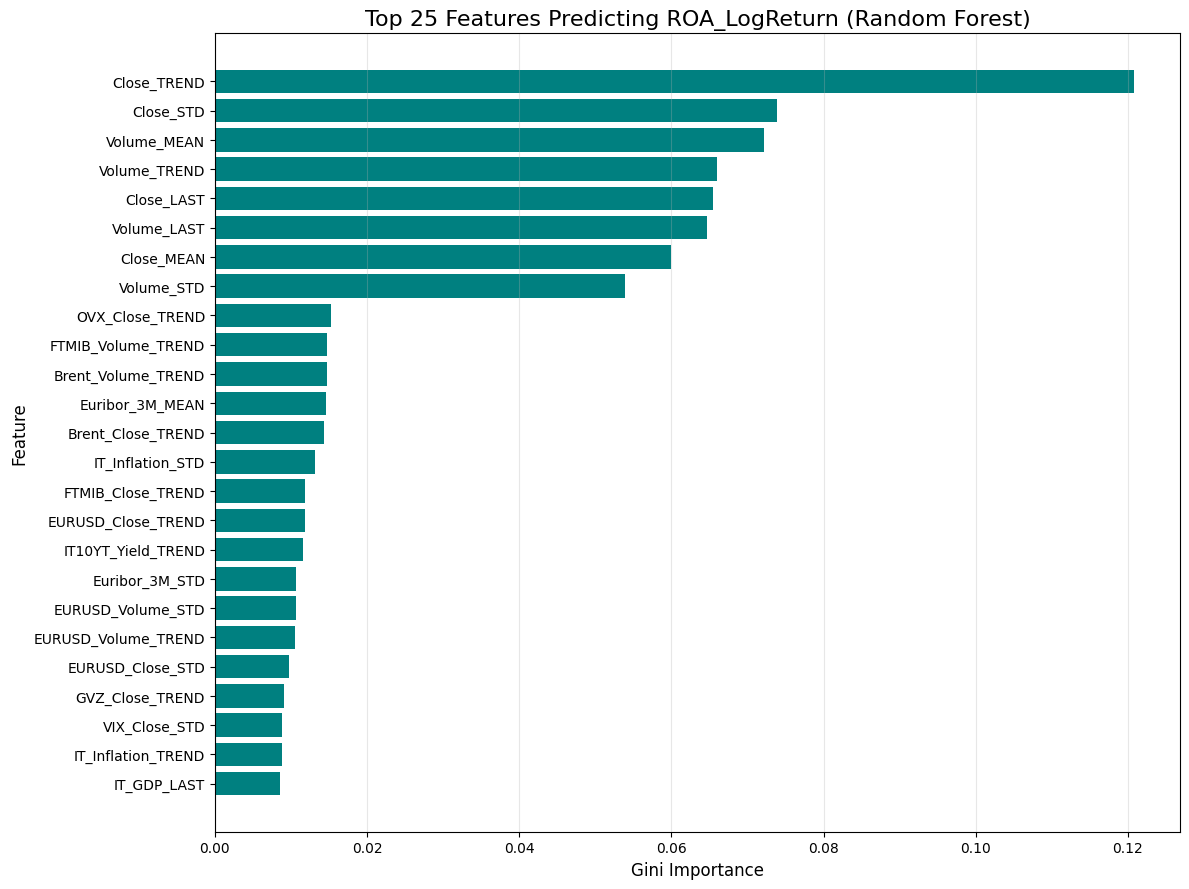

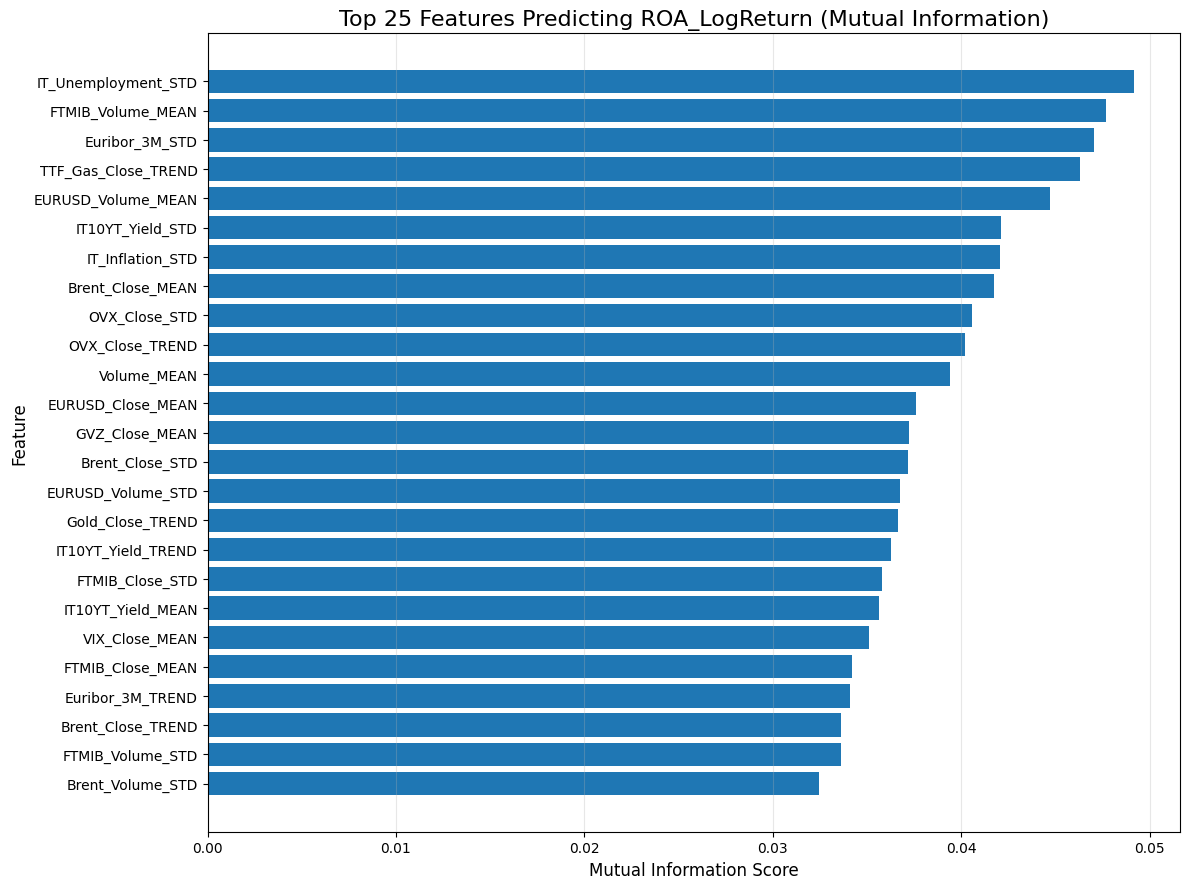

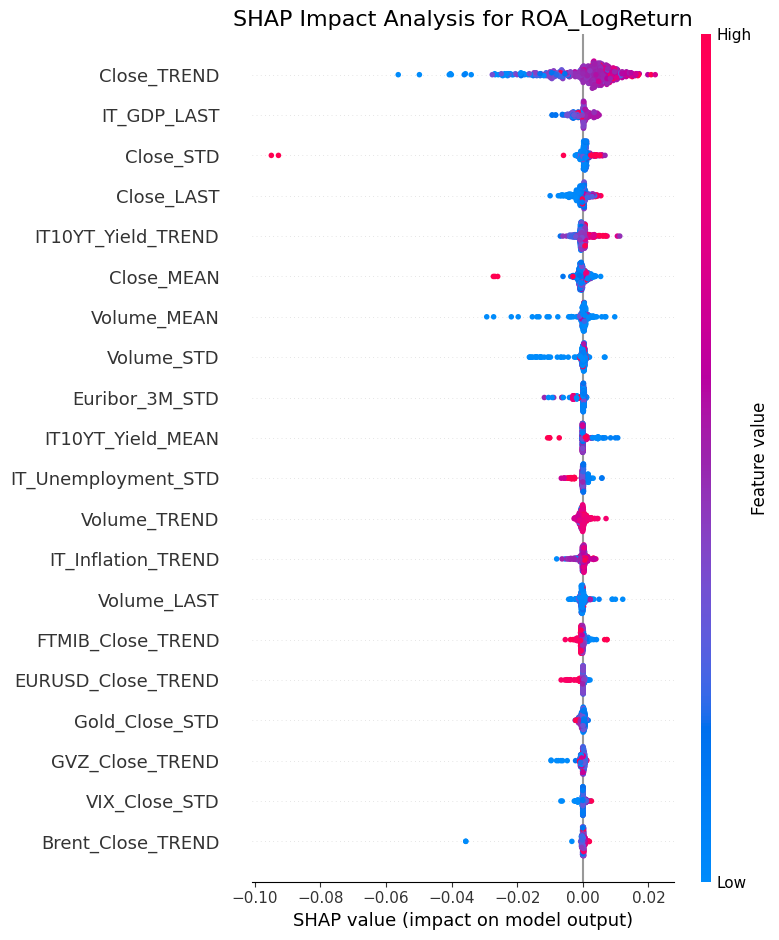


                         Net_Income_LogReturn                         
Total valid 365-day windows extracted: 2167

Top 10 features by Mutual Information:
           Feature  MI_Regression
       Volume_MEAN       0.063925
  DE10YT_Yield_STD       0.057185
 FTMIB_Volume_MEAN       0.054295
EURUSD_Volume_MEAN       0.053553
        Volume_STD       0.052194
    Euribor_3M_STD       0.048975
    GVZ_Close_MEAN       0.047379
       Volume_LAST       0.046089
   Gold_Close_MEAN       0.045423
    Gold_Close_STD       0.044537

Best RF Params for Net_Income_LogReturn: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'absolute_error', 'bootstrap': True}
Train -> MAE: 3.5251 | RMSE: 7.6787 | R2: 0.1092 | Avg % Diff: 550778.96% | Median % Diff: 96.89% | WAPE: 94.89% | sMAPE: 145.46%
Test  -> MAE: 4.4041 | RMSE: 8.8320 | R2: -0.0127 | Avg % Diff: 463.07% | Median % Diff: 99.64% | WAPE: 104.18% | sMAPE: 151.97%


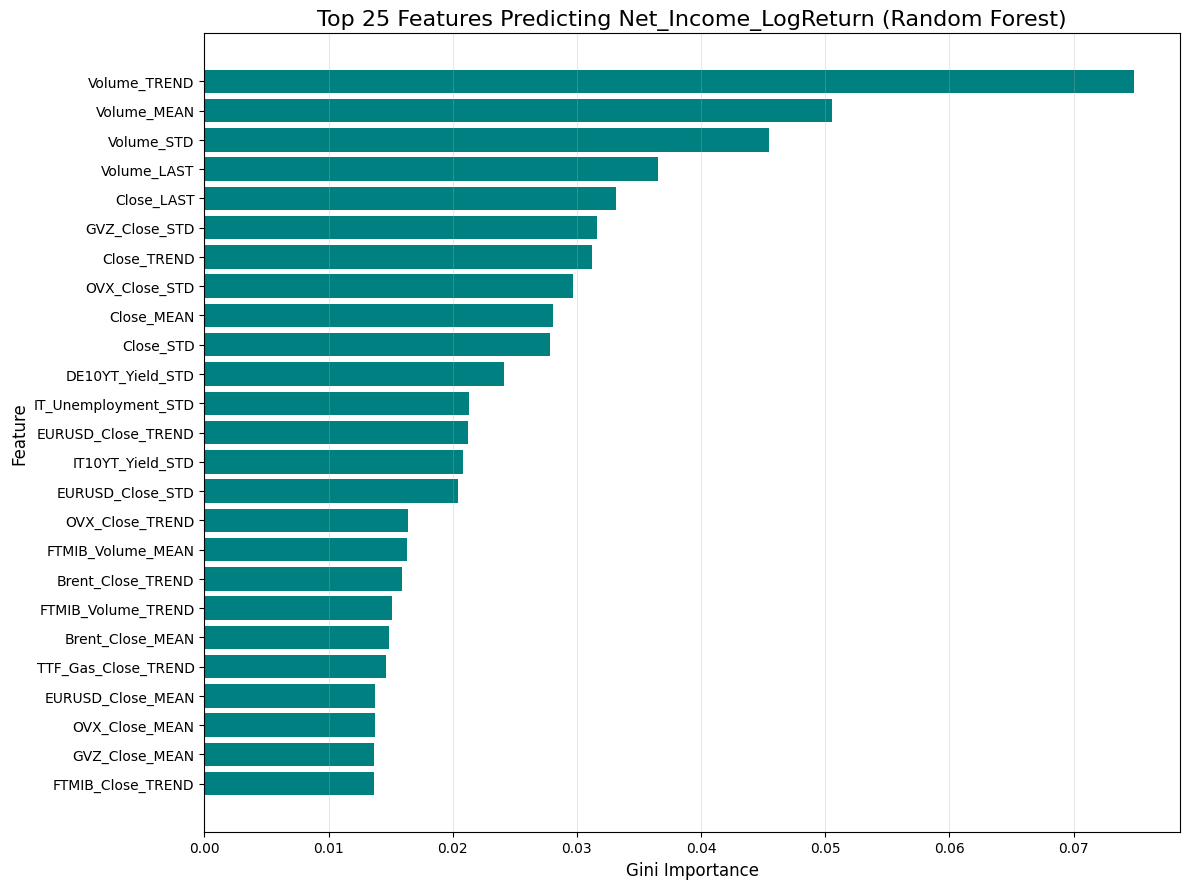

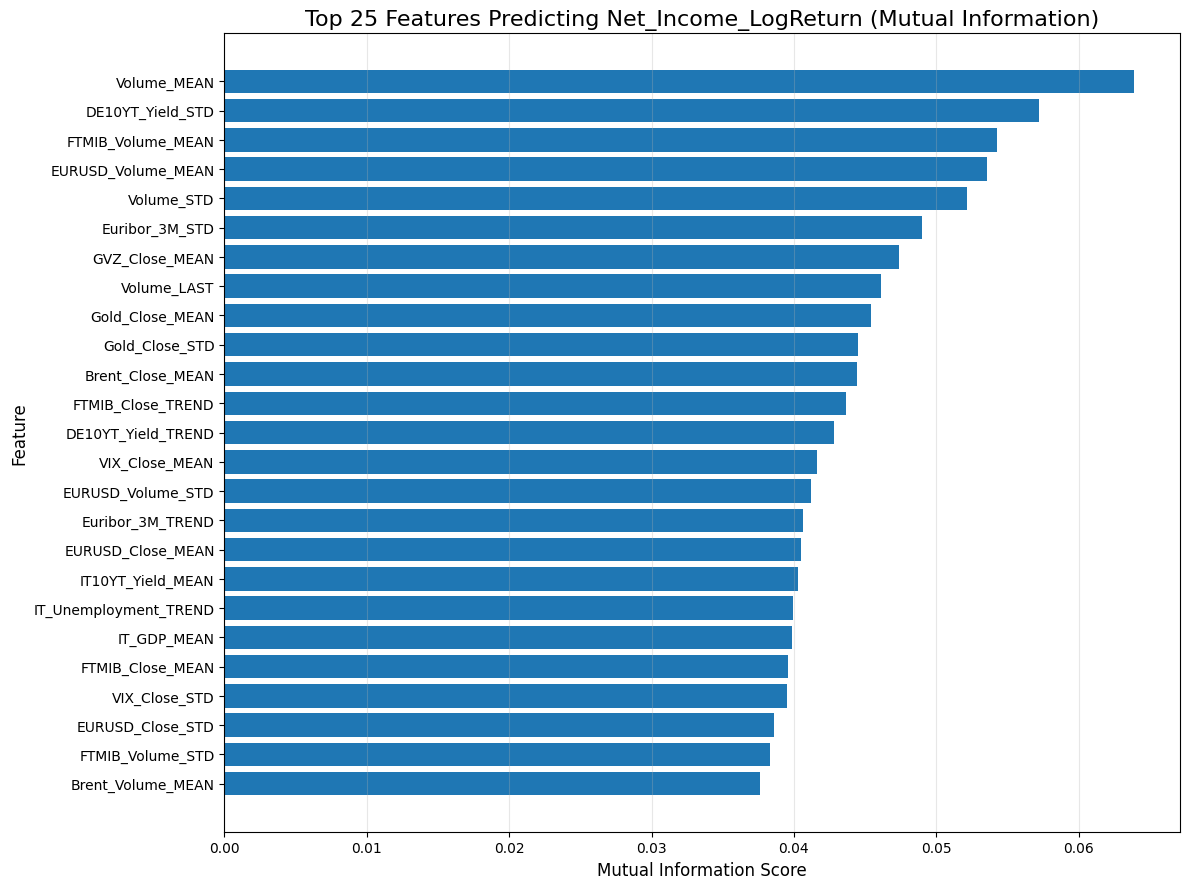

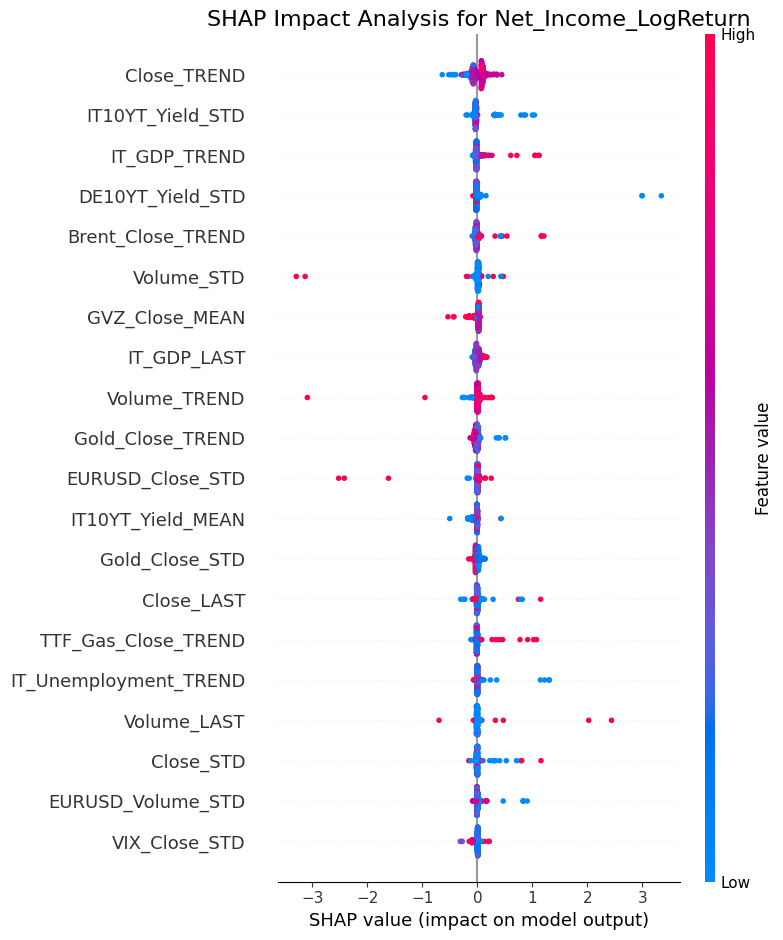


Final Test Performance Summary (Momentum Models)
              Target   Test_R2  Test_RMSE  Test_MAE  AvgPctDiff_%  MedianPctDiff_%     WAPE_%    sMAPE_%
    EBITDA_LogReturn -0.013591   6.501346  2.388059    242.227391        95.554042 104.144361 133.287996
       ROA_LogReturn  0.003747   0.094823  0.043298 339968.456924       100.615676 101.722485 143.465912
Net_Income_LogReturn -0.012662   8.832047  4.404059    463.068482        99.639687 104.179061 151.974719


In [ ]:
performance_summary = []
df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in log_targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]

            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]

            if len(window) <= 200:
                continue

            window_stats = {'Company': company}

            for feat in features:
                series = window[feat].dropna()

                if series.empty:
                    window_stats[f"{feat}_MEAN"] = 0.0
                    window_stats[f"{feat}_STD"] = 0.0
                    window_stats[f"{feat}_LAST"] = 0.0
                    window_stats[f"{feat}_TREND"] = 0.0
                else:
                    values = series.values.astype(float)
                    window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                    window_stats[f"{feat}_STD"] = float(np.std(values))
                    window_stats[f"{feat}_LAST"] = float(values[-1])

                    if len(values) > 1:
                        x_axis = np.arange(len(values), dtype=float)
                        slope = np.polyfit(x_axis, values, deg=1)[0]
                    else:
                        slope = 0.0
                    window_stats[f"{feat}_TREND"] = float(slope)

            X_aggregated.append(window_stats)
            y_values.append(float(target_value))

    X_df = pd.DataFrame(X_aggregated)
    y_series = pd.Series(y_values)
    print(f"Total valid 365-day windows extracted: {len(X_df)}")

    if len(X_df) < 30:
        print(f"Not enough samples for reliable train/test evaluation on {target}. Skipping.")
        continue

    # Remove the entity bias (Company ID) for pure macro evaluation
    X_df = X_df.drop(columns=['Company']).fillna(0.0)

    # 2. Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42
    )

    mi_df, mi_col = compute_mutual_information(X_train, y_train.values, task='regression')
    print("\nTop 10 features by Mutual Information:")
    print(mi_df.head(10).to_string(index=False))

    # 3. Fit a single, robust Random Forest for Momentum Prediction
    # NOTE: ensure fit_rf and regression_metrics are defined in your notebook
    rf, best_params = fit_rf(X_train, y_train.values)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    train_metrics = regression_metrics(y_train.values, y_train_pred)
    test_metrics = regression_metrics(y_test.values, y_test_pred)

    print(f"\nBest RF Params for {target}: {best_params}")
    print(f"Train -> MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f} | Avg % Diff: {train_metrics['AvgPctDiff']:.2f}% | Median % Diff: {train_metrics['MedianPctDiff']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}% | sMAPE: {train_metrics['sMAPE']:.2f}%")
    print(f"Test  -> MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f} | Avg % Diff: {test_metrics['AvgPctDiff']:.2f}% | Median % Diff: {test_metrics['MedianPctDiff']:.2f}% | WAPE: {test_metrics['WAPE']:.2f}% | sMAPE: {test_metrics['sMAPE']:.2f}%")

    performance_summary.append({
        'Target': target,
        'Test_R2': test_metrics['R2'],
        'Test_RMSE': test_metrics['RMSE'],
        'Test_MAE': test_metrics['MAE'],
        'AvgPctDiff_%': test_metrics['AvgPctDiff'],
        'MedianPctDiff_%': test_metrics['MedianPctDiff'],
        'WAPE_%': test_metrics['WAPE'],
        'sMAPE_%': test_metrics['sMAPE']
    })

    # 4. Feature Importance Plot
    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(25).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 9))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 25 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4b. Mutual Information Plot
    top_mi = mi_df.head(25).sort_values(by=mi_col, ascending=True)
    plt.figure(figsize=(12, 9))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 25 Features Predicting {target} (Mutual Information)', fontsize=16)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5. SHAP Summary Plot
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test, check_additivity=False)

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (Momentum Models)")
print("=" * 70)
print(performance_summary_df.to_string(index=False))

## Part 3: Classification of direction

The results from Part 1 reveal a critical structural bias in predicting absolute financial variables, commonly known as the "Size Trap". 
For raw targets like EBITDA and Net Income, the models assigned overwhelming importance to trading volumes (`Volume_MEAN` and `Volume_STD`). Because the dataset contains both Small Cap and Large Cap companies, the algorithm stops analyzing financial performance and instead uses Volume as a proxy for Market Capitalization. It essentially learns a basic heuristic: companies with high trading volumes are massive, therefore their EBITDA will be in the billions.

To build a true predictive model that evaluates economic performance rather than company scale, the target variables are changed using two key transformations:
1. **Quarter-over-Quarter (QoQ) Momentum:** Instead of predicting the absolute level of the fundamentals, we calculate the percentage change compared to the previous quarter. A +5% growth is mathematically identical for a multi-national corporation and a local startup, effectively neutralizing the size bias.
2. **Directional Target (Classification):** the QoQ momentum is further refined into a binary target: **1 (Up)** if the fundamental improved, and **0 (Down)** if it worsened. 

By shifting the architecture from Regression to **Binary Classification**, we force the algorithms to ignore the company's size and focus exclusively on the macroeconomic drivers and market signals that dictate economic expansion or contraction.


                         EBITDA_Direction_Up                          
Total valid 365-day windows extracted for classification: 2126

Top 10 features by Mutual Information:
            Feature  MI_Classif
        Close_TREND    0.065491
    Euribor_3M_LAST    0.052037
  EURUSD_Close_LAST    0.043569
IT_Unemployment_STD    0.038826
    GVZ_Close_TREND    0.036555
     OVX_Close_LAST    0.036032
  FTMIB_Close_TREND    0.033472
   FTMIB_Close_LAST    0.033024
        IT_GDP_MEAN    0.032597
   DE10YT_Yield_STD    0.031755
Fitting 4 folds for each of 150 candidates, totalling 600 fits
Best XGB Params for EBITDA_Direction_Up: {'subsample': 0.6, 'n_estimators': 1000, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 1.0}

--- Test Set Performance ---
Accuracy: 0.5634
ROC-AUC:  0.6387

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.60      0.50       156
           1       0.70      0.54      0.61       270



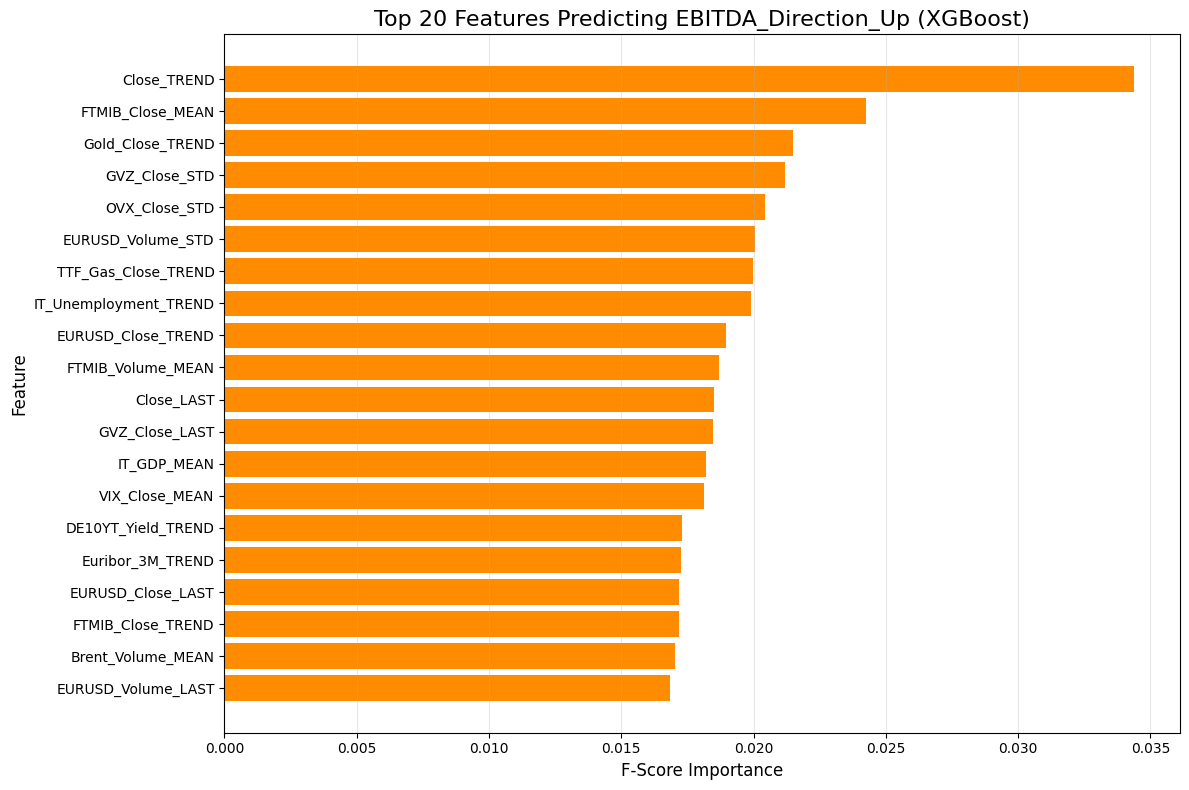

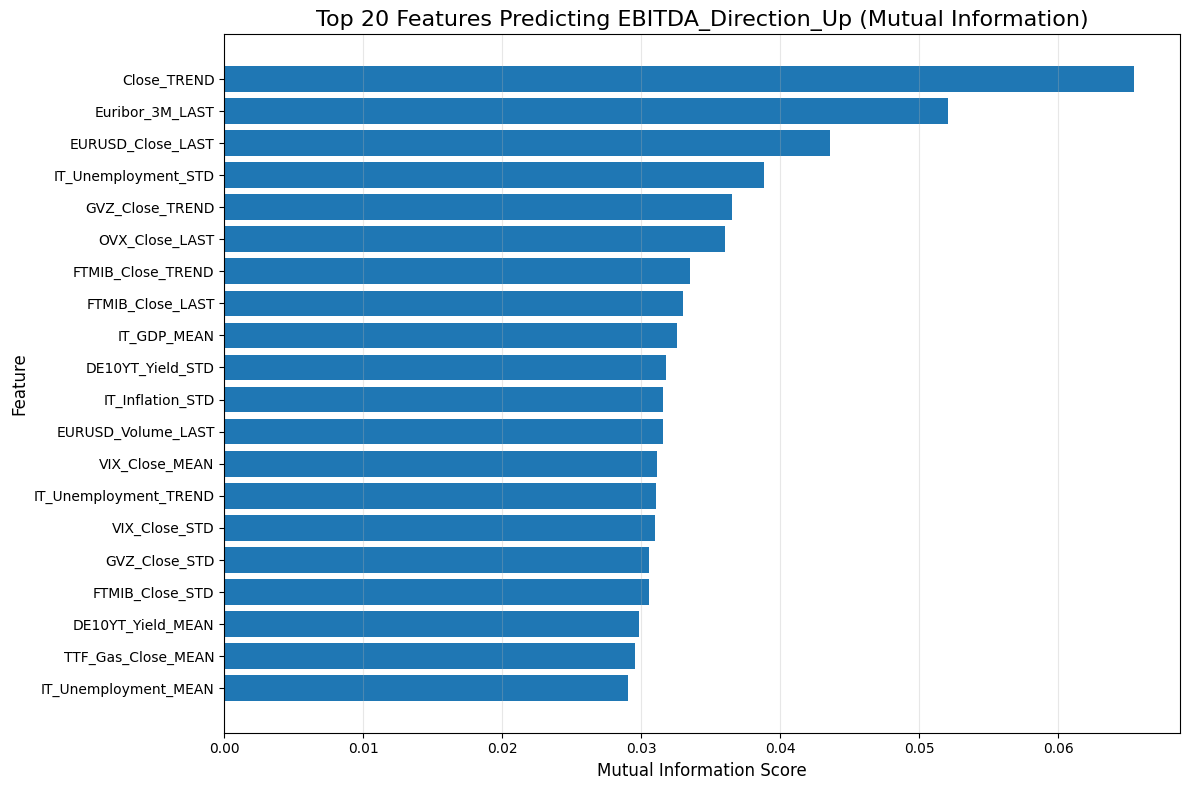

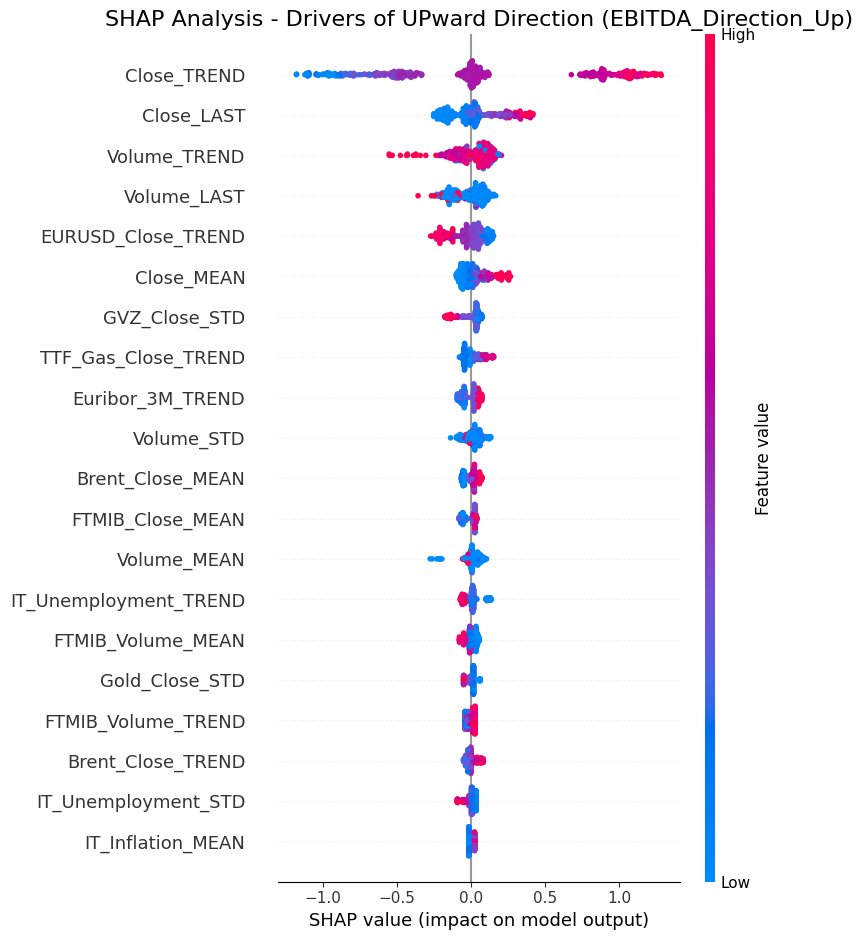


                           ROA_Direction_Up                           
Total valid 365-day windows extracted for classification: 2165

Top 10 features by Mutual Information:
          Feature  MI_Classif
 DE10YT_Yield_STD    0.044903
Brent_Close_TREND    0.044304
Brent_Volume_MEAN    0.043039
  Euribor_3M_LAST    0.041088
      Close_TREND    0.040500
 EURUSD_Close_STD    0.039575
   GVZ_Close_LAST    0.038802
EURUSD_Close_MEAN    0.036974
 FTMIB_Volume_STD    0.036291
FTMIB_Volume_LAST    0.035867
Fitting 4 folds for each of 150 candidates, totalling 600 fits
Best XGB Params for ROA_Direction_Up: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 0.6}

--- Test Set Performance ---
Accuracy: 0.6189
ROC-AUC:  0.6663

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.64      0.61       206
           1       0.65      0.60      0.62       227

    accuracy              

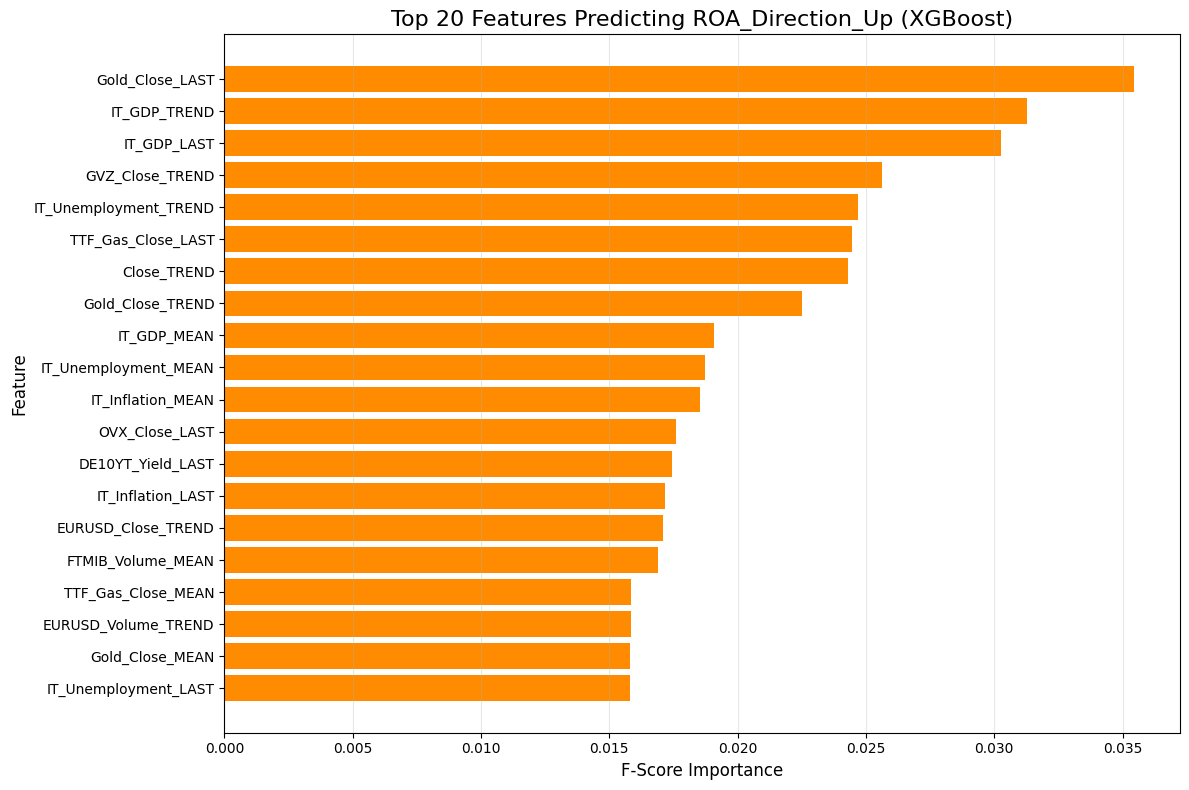

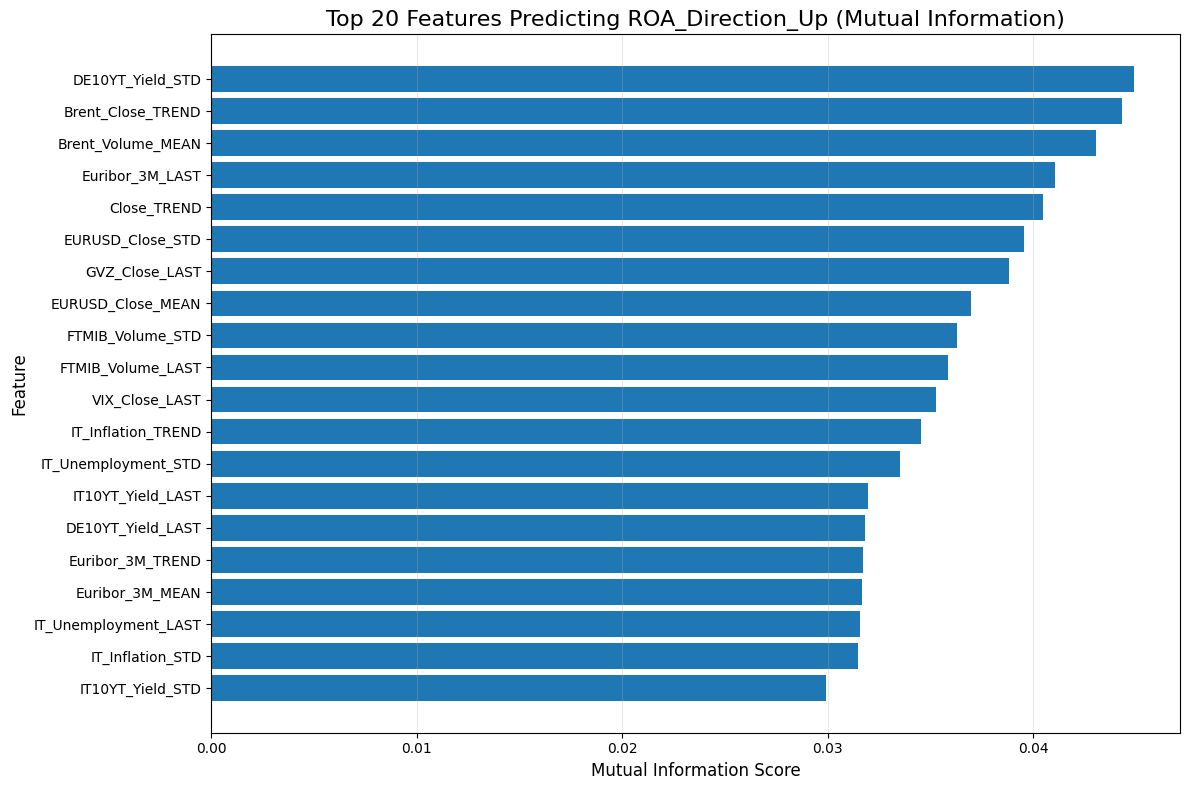

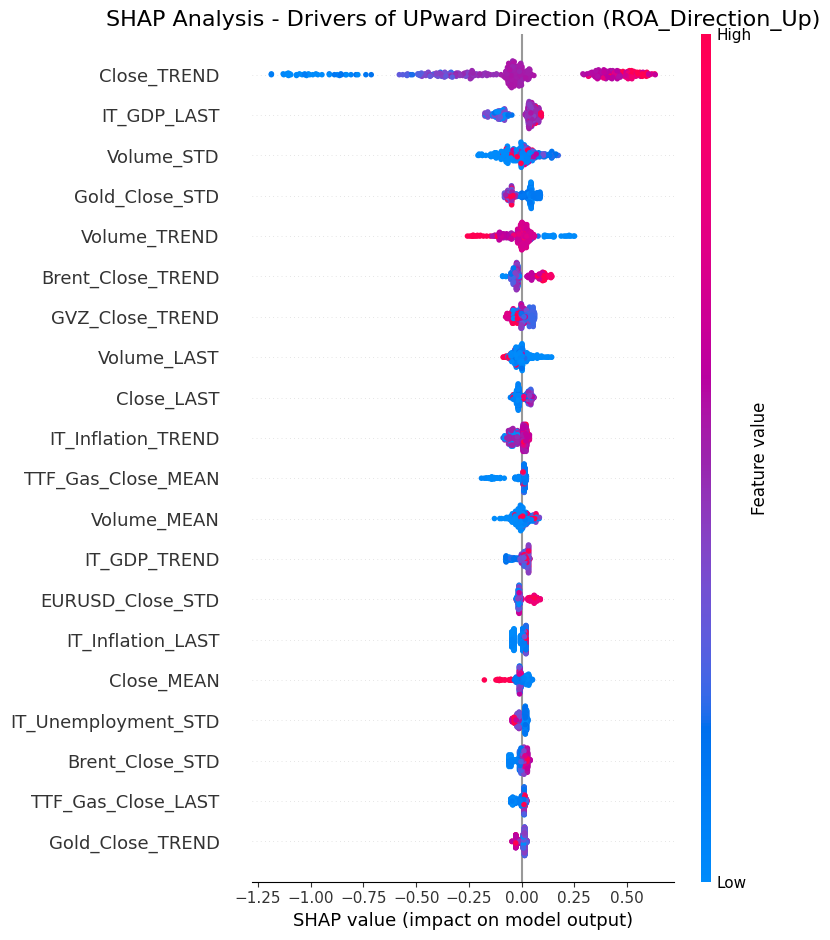


                       Net_Income_Direction_Up                        
Total valid 365-day windows extracted for classification: 2167

Top 10 features by Mutual Information:
           Feature  MI_Classif
   Euribor_3M_MEAN    0.044544
TTF_Gas_Close_LAST    0.044126
  FTMIB_Close_LAST    0.043051
       IT_GDP_LAST    0.042860
   GVZ_Close_TREND    0.037443
  FTMIB_Close_MEAN    0.036794
  DE10YT_Yield_STD    0.036269
  IT10YT_Yield_STD    0.035327
  Brent_Close_LAST    0.035193
 FTMIB_Volume_MEAN    0.033580
Fitting 4 folds for each of 150 candidates, totalling 600 fits
Best XGB Params for Net_Income_Direction_Up: {'subsample': 0.6, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 0.8}

--- Test Set Performance ---
Accuracy: 0.5876
ROC-AUC:  0.6439

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.63      0.55       175
           1       0.69      0.56      0.62       259

    acc

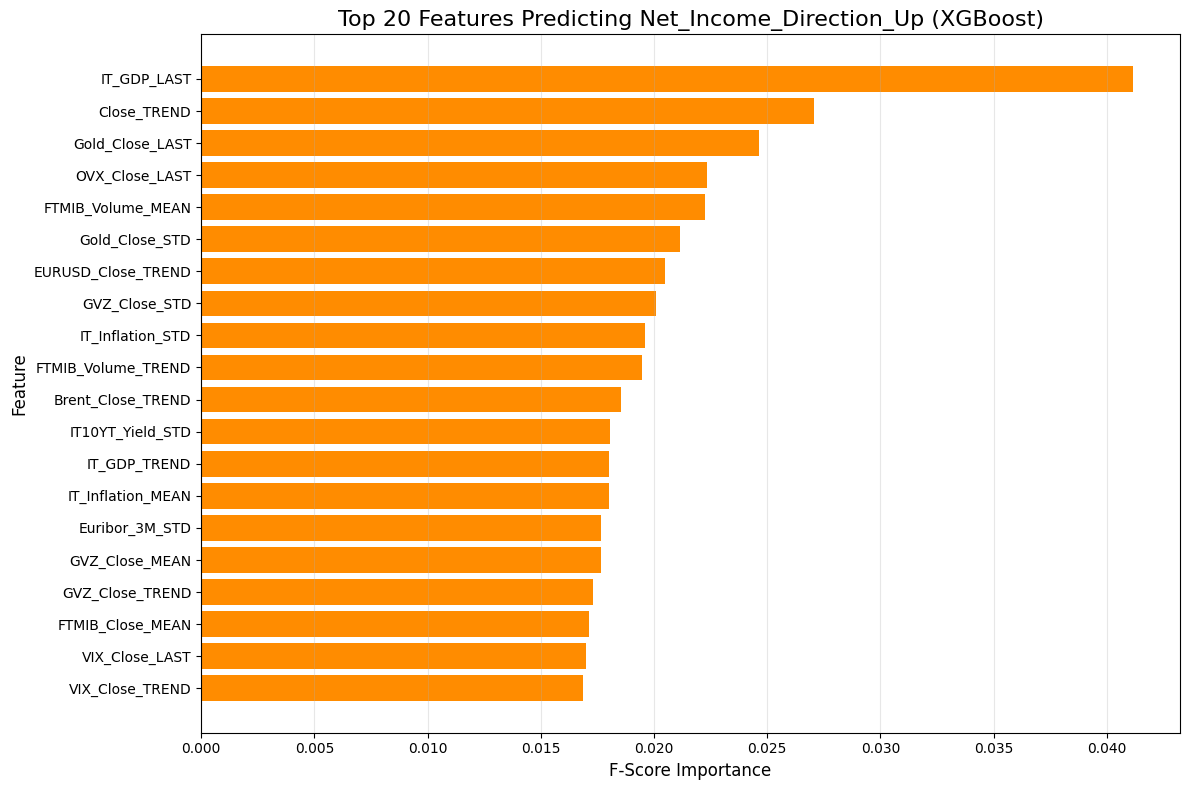

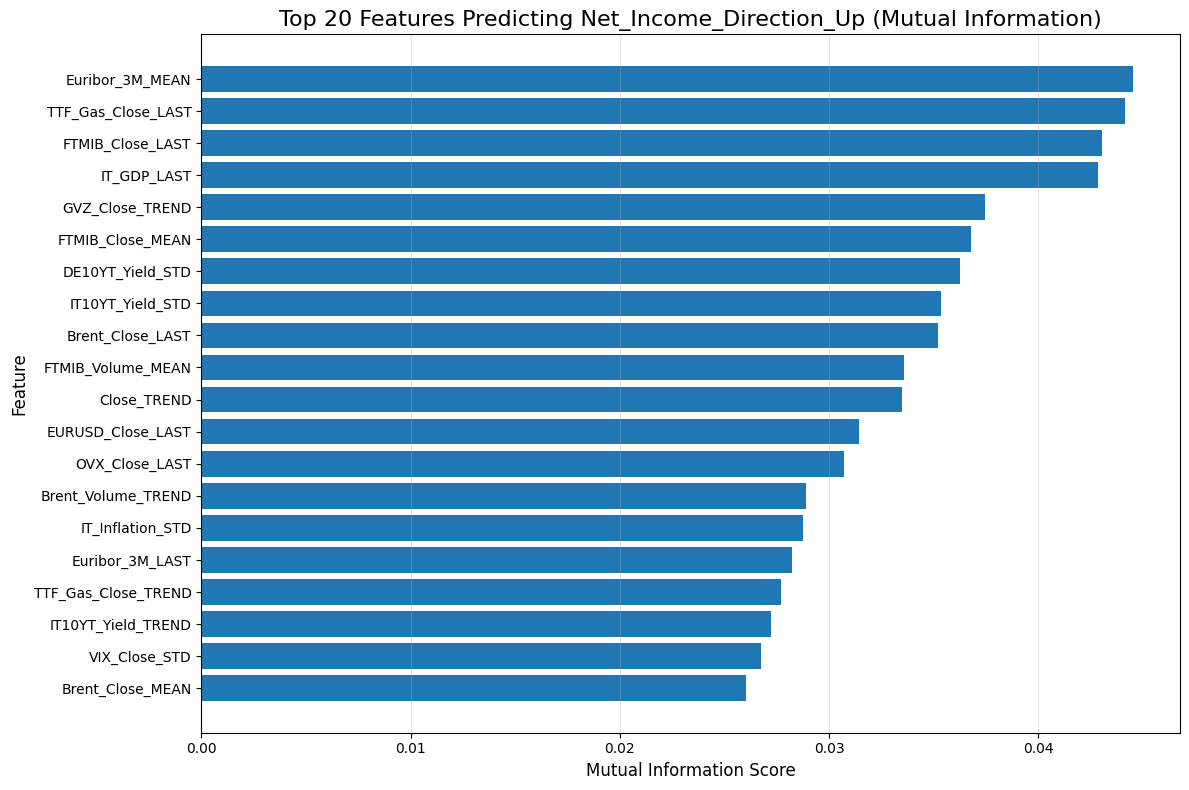

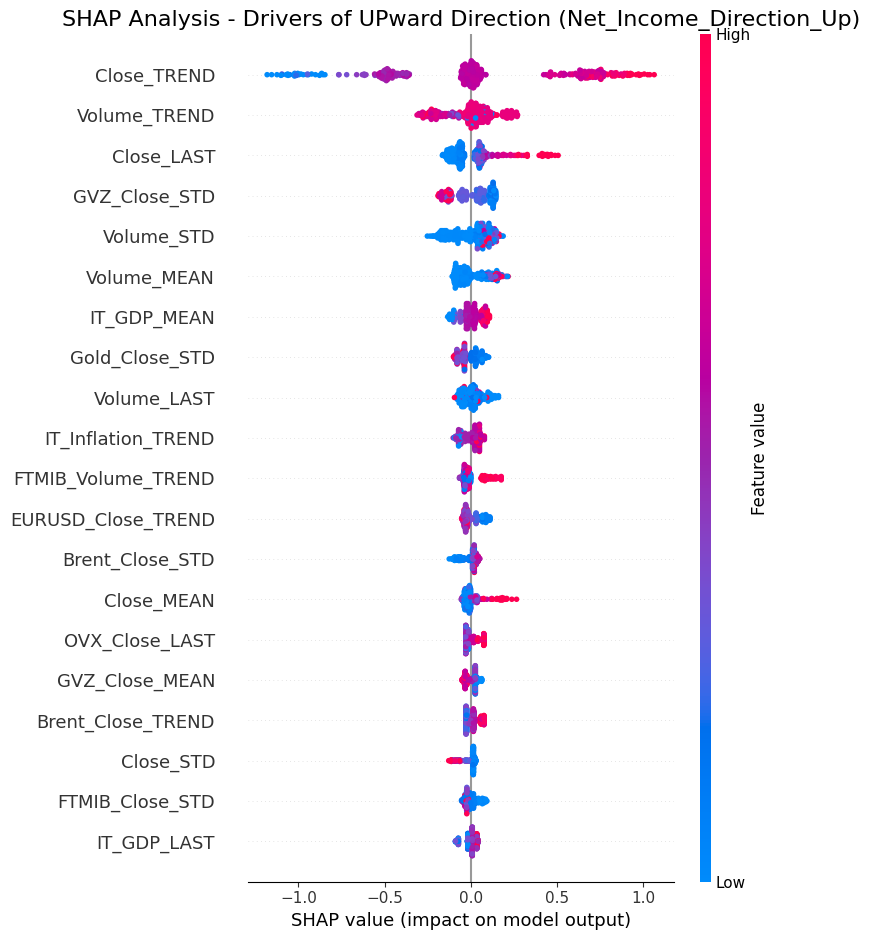


Final Test Performance Summary (XGBoost Classification Models)
                 Target  Test_Accuracy  Test_ROC_AUC
    EBITDA_Direction_Up       0.563380      0.638711
       ROA_Direction_Up       0.618938      0.666300
Net_Income_Direction_Up       0.587558      0.643916


In [13]:
performance_summary = []
df_yoy = df_yoy.sort_values(by=['Company', 'Date']).reset_index(drop=True)

directional_targets = []

for target in targets:
    dir_col = f"{target}_Direction_Up"
    directional_targets.append(dir_col)

    valid_reports = df_yoy[df_yoy[target].notna()].copy()
    valid_reports[dir_col] = valid_reports.groupby('Company')[target].transform(
        lambda x: np.where(x - x.shift(1) > 0, 1, 0)
    )
    valid_reports.loc[valid_reports.groupby('Company')[target].shift(1).isna(), dir_col] = np.nan
    df_yoy[dir_col] = valid_reports[dir_col]

df_by_company = {company: grp.sort_values('Date') for company, grp in df_yoy.groupby('Company')}

for target in directional_targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    for company, company_df in df_by_company.items():
        company_targets = company_df[company_df[target].notna()].copy()

        if company_targets.empty:
            continue

        for _, row in company_targets.iterrows():
            target_date = row['Date']
            target_value = row[target]
            
            start_date = target_date - pd.Timedelta(days=365)
            window = company_df[(company_df['Date'] > start_date) & (company_df['Date'] <= target_date)]
            
            if len(window) > 200:
                window_stats = {}
                for feat in features:
                    series = window[feat].dropna()
                    if series.empty:
                        window_stats[f"{feat}_MEAN"] = 0.0
                        window_stats[f"{feat}_STD"] = 0.0
                        window_stats[f"{feat}_LAST"] = 0.0
                        window_stats[f"{feat}_TREND"] = 0.0
                    else:
                        values = series.values.astype(float)
                        window_stats[f"{feat}_MEAN"] = float(np.mean(values))
                        window_stats[f"{feat}_STD"] = float(np.std(values))
                        window_stats[f"{feat}_LAST"] = float(values[-1])
                        
                        if len(values) > 1:
                            x_axis = np.arange(len(values), dtype=float)
                            slope = np.polyfit(x_axis, values, deg=1)[0]
                        else:
                            slope = 0.0
                        window_stats[f"{feat}_TREND"] = float(slope)

                X_aggregated.append(window_stats)
                y_values.append(int(target_value))

    X_df = pd.DataFrame(X_aggregated).fillna(0)
    y_series = pd.Series(y_values)
    
    print(f"Total valid 365-day windows extracted for classification: {len(X_df)}")
    if len(X_df) < 50:
        print("Not enough samples. Skipping.")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.2, random_state=42, stratify=y_series
    )
    
    mi_df, mi_col = compute_mutual_information(X_train, y_train.values, task='classification')
    print("\nTop 10 features by Mutual Information:")
    print(mi_df.head(10).to_string(index=False))

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    xgb_model, best_params = fit_xgb_classifier(X_train_scaled, y_train)
    print(f"Best XGB Params for {target}: {best_params}")
    
    y_pred = xgb_model.predict(X_test_scaled)
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print("\n--- Test Set Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    performance_summary.append({
        'Target': target,
        'Best_Params': str(best_params),
        'Test_Accuracy': accuracy,
        'Test_ROC_AUC': roc_auc
    })

    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(20).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='darkorange')
    plt.title(f'Top 20 Features Predicting {target} (XGBoost)', fontsize=16)
    plt.xlabel('F-Score Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Mutual Information Plot
    top_mi = mi_df.head(20).sort_values(by=mi_col, ascending=True)
    plt.figure(figsize=(12, 8))
    plt.barh(top_mi['Feature'], top_mi[mi_col], color='#1f77b4')
    plt.title(f'Top 20 Features Predicting {target} (Mutual Information)', fontsize=16)
    plt.xlabel('Mutual Information Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # SHAP Impact Plot
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_values, list):
        shap_values_target = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_target = shap_values[:, :, 1]
    else:
        shap_values_target = shap_values
        
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Analysis - Drivers of UPward Direction ({target})", fontsize=16)
    shap.summary_plot(shap_values_target, X_test, feature_names=X_test.columns, plot_type="dot", show=False)
    plt.tight_layout()
    plt.show()

performance_summary_df = pd.DataFrame(performance_summary)
print("\n" + "=" * 70)
print("Final Test Performance Summary (XGBoost Classification Models)")
print("=" * 70)
print(performance_summary_df[['Target', 'Test_Accuracy', 'Test_ROC_AUC']].to_string(index=False))